In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras
from keras import layers

In [19]:
IMAGE_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 200
CLASSES = 2

In [20]:
# 1. Dataset Loading
(ds_train, ds_test), ds_info = tfds.load("cats_vs_dogs", split=["train[:90%]", "train[90%:]"], shuffle_files=True, as_supervised=True, with_info=True) #

def preprocess_image(image, label):
    # Resize to 64x64
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    # Introduce random horizontal flipping to real images
    image = tf.image.random_flip_left_right(image)
    # Normalize to [-1, 1]
    image = (image - 127.5) / 127.5
    # Ensure label is integer
    label = tf.cast(label, tf.int32)
    return image, label

# 2. Preprocessing Pipeline
# Add num_parallel_calls and increase shuffle buffer for better mixing
train_dataset = ds_train.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = ds_test.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

In [21]:
def build_generator(latent_dim, num_classes):
    # Inputs: Noise vector and Label
    target_label = layers.Input(shape=(1,), name="label_input")
    noise = layers.Input(shape=(latent_dim,), name="noise_input")

    # Label embedding: Map label to a vector space
    label_embedding = layers.Embedding(num_classes, latent_dim)(target_label)
    label_embedding = layers.Flatten()(label_embedding)

    # Combine noise and label
    combined_input = layers.Concatenate()([noise, label_embedding])

    # Foundation for 4x4 image
    x = layers.Dense(4 * 4 * 512, use_bias=False)(combined_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((4, 4, 512))(x)

    # Upsampling to 8x8, 16x16, 32x32, then 64x64
    x = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final output layer: 64x64x3 with tanh activation
    out = layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", activation="tanh")(x)

    return keras.Model([noise, target_label], out, name="generator")

generator = build_generator(LATENT_DIM, CLASSES)

In [22]:
def build_discriminator(img_shape, num_classes):
    # Inputs: Image and Label
    img_input = layers.Input(shape=img_shape, name="image_input")
    label_input = layers.Input(shape=(1,), name="label_input")

    # Embed label and reshape to match image dimensions for concatenation
    label_embedding = layers.Embedding(num_classes, 64 * 64)(label_input)
    label_embedding = layers.Reshape((64, 64, 1))(label_embedding)

    # Concatenate label channel to image
    # Deliberately using Concatenate to allow the discriminator to learn how to use label information, 
    # rather than forcing it through multiplication which might be too restrictive.
    combined_input = layers.Concatenate()([img_input, label_embedding])

    # Downsample: 64x64 -> 32x32 -> 16x16 -> 8x8
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same")(combined_input)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)

    # Final Classification
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model([img_input, label_input], out, name="discriminator")

discriminator = build_discriminator(img_shape=(64, 64, 3), num_classes=2)

In [23]:
cross_entropy = keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    # Use one-sided label smoothing (0.9 instead of 1.0)
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Adam optimizers with a learning rate of 1e-4 and beta_1 of 0.5 are commonly used for GANs to stabilize training.
# Trying with different combinations of learning rates for generator and discriminator to see if it improves convergence.
gen_optimizer = keras.optimizers.legacy.Adam(5e-5, beta_1=0.5)
# Implement Two Time-Scale Update Rule (TTUR): Use different learning rates for generator and discriminator to improve convergence.
disc_optimizer = keras.optimizers.legacy.Adam(2e-4, beta_1=0.5)

In [24]:
def generate_and_plot(num_examples=10):
    # Labels: 0 for Cat, 1 for Dog (randomly chosen for visualization)
    random_labels = tf.random.uniform((num_examples,), minval=0, maxval=2, dtype=tf.int32)
    noise = tf.random.normal([num_examples, LATENT_DIM])
    
    # Generate images
    generated_images = generator([noise, random_labels], training=False)
    
    # Rescale to [0, 1] for plotting
    generated_images = (generated_images + 1) / 2.0

    cols = 7  # Number of images per row
    rows = (num_examples + cols - 1) // cols  # Auto-calculate rows needed
    plt.figure(figsize=(cols * 4, rows * 4))  # 4 inches per image (width x height)    
    for i in range(num_examples):
        plt.subplot(rows, cols, i+1)
        plt.imshow(generated_images[i])
        label_text = "Dog" if random_labels[i] == 1 else "Cat"
        plt.title(f"Label: {label_text}")
        plt.axis("off")
        plt.tight_layout()
    plt.show()

Epoch 1: Gen Loss: 3.7745, Disc Loss: 0.4455
Epoch 2: Gen Loss: 2.8540, Disc Loss: 0.6368
Epoch 2: Gen Loss: 2.8540, Disc Loss: 0.6368
Epoch 3: Gen Loss: 2.9298, Disc Loss: 0.5714
Epoch 3: Gen Loss: 2.9298, Disc Loss: 0.5714
Epoch 4: Gen Loss: 2.4946, Disc Loss: 0.6784
Epoch 4: Gen Loss: 2.4946, Disc Loss: 0.6784
Epoch 5: Gen Loss: 2.1415, Disc Loss: 0.7627
Epoch 5: Gen Loss: 2.1415, Disc Loss: 0.7627
Epoch 6: Gen Loss: 1.8052, Disc Loss: 0.8555
Epoch 6: Gen Loss: 1.8052, Disc Loss: 0.8555
Epoch 7: Gen Loss: 1.6063, Disc Loss: 0.9296
Epoch 7: Gen Loss: 1.6063, Disc Loss: 0.9296
Epoch 8: Gen Loss: 1.5763, Disc Loss: 0.9603
Epoch 8: Gen Loss: 1.5763, Disc Loss: 0.9603
Epoch 9: Gen Loss: 1.5352, Disc Loss: 0.9494
Epoch 9: Gen Loss: 1.5352, Disc Loss: 0.9494
Epoch 10: Gen Loss: 1.5969, Disc Loss: 0.9388
Epoch 10: Gen Loss: 1.5969, Disc Loss: 0.9388


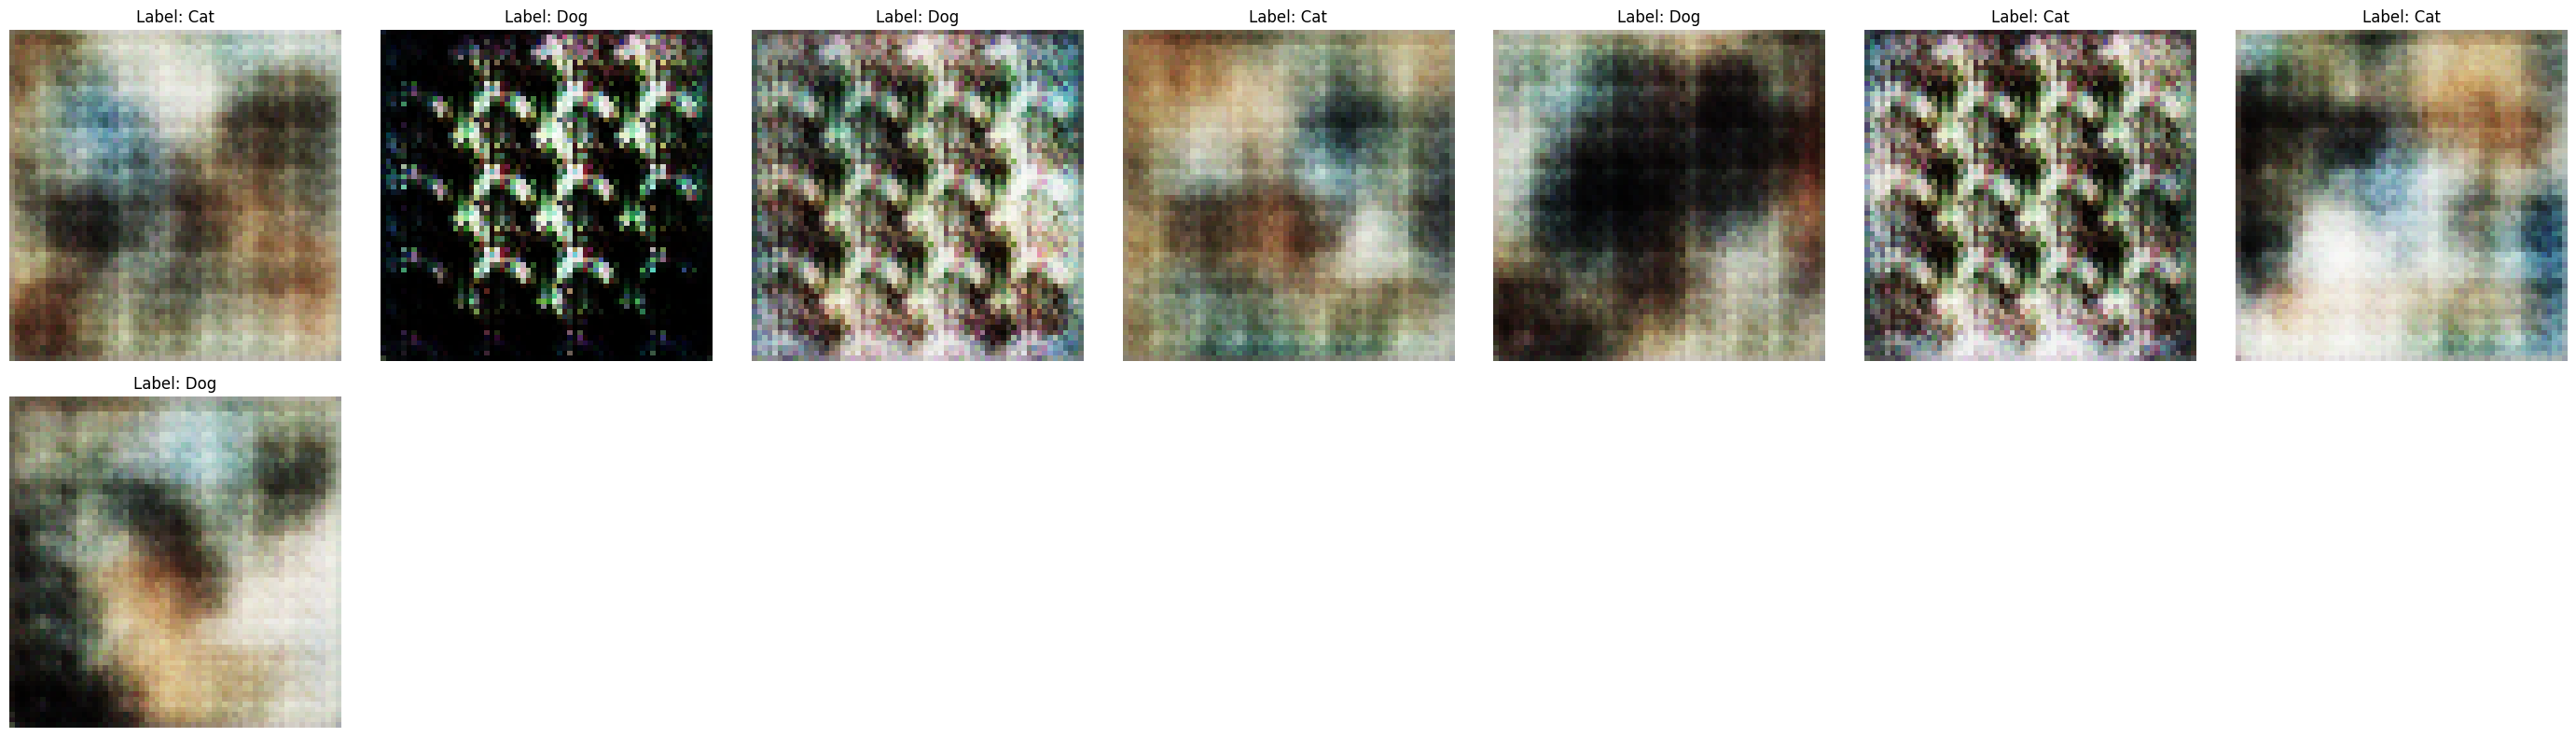

Epoch 11: Gen Loss: 1.5762, Disc Loss: 0.9557
Epoch 12: Gen Loss: 1.4215, Disc Loss: 1.0026
Epoch 12: Gen Loss: 1.4215, Disc Loss: 1.0026
Epoch 13: Gen Loss: 1.4807, Disc Loss: 0.9930
Epoch 13: Gen Loss: 1.4807, Disc Loss: 0.9930
Epoch 14: Gen Loss: 1.4560, Disc Loss: 1.0026
Epoch 14: Gen Loss: 1.4560, Disc Loss: 1.0026
Epoch 15: Gen Loss: 1.3570, Disc Loss: 1.0377
Epoch 15: Gen Loss: 1.3570, Disc Loss: 1.0377
Epoch 16: Gen Loss: 1.2635, Disc Loss: 1.0935
Epoch 16: Gen Loss: 1.2635, Disc Loss: 1.0935
Epoch 17: Gen Loss: 1.1977, Disc Loss: 1.1328
Epoch 17: Gen Loss: 1.1977, Disc Loss: 1.1328
Epoch 18: Gen Loss: 1.1665, Disc Loss: 1.1643
Epoch 18: Gen Loss: 1.1665, Disc Loss: 1.1643
Epoch 19: Gen Loss: 1.0876, Disc Loss: 1.1893
Epoch 19: Gen Loss: 1.0876, Disc Loss: 1.1893
Epoch 20: Gen Loss: 1.0781, Disc Loss: 1.2065
Epoch 20: Gen Loss: 1.0781, Disc Loss: 1.2065


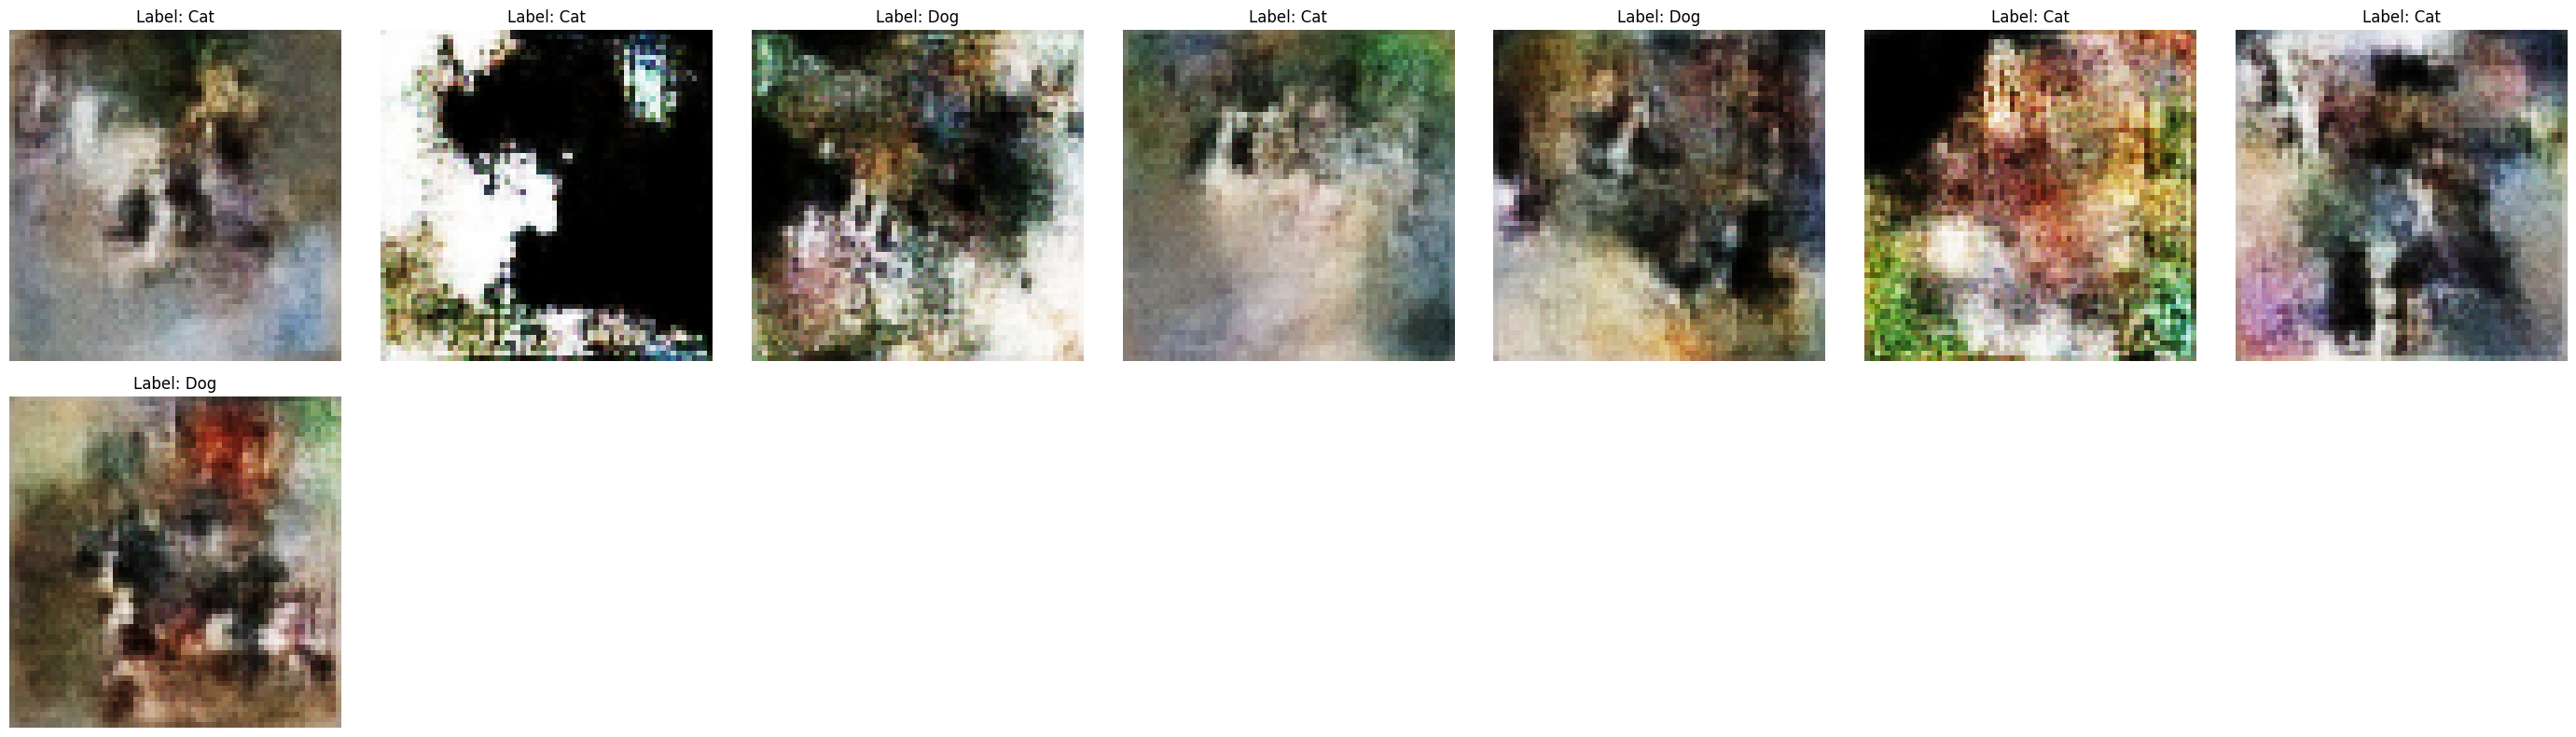

Epoch 21: Gen Loss: 1.0623, Disc Loss: 1.2149
Epoch 22: Gen Loss: 1.0603, Disc Loss: 1.2294
Epoch 22: Gen Loss: 1.0603, Disc Loss: 1.2294
Epoch 23: Gen Loss: 1.0611, Disc Loss: 1.2141
Epoch 23: Gen Loss: 1.0611, Disc Loss: 1.2141
Epoch 24: Gen Loss: 1.0570, Disc Loss: 1.2141
Epoch 24: Gen Loss: 1.0570, Disc Loss: 1.2141
Epoch 25: Gen Loss: 1.0494, Disc Loss: 1.2201
Epoch 25: Gen Loss: 1.0494, Disc Loss: 1.2201
Epoch 26: Gen Loss: 1.0348, Disc Loss: 1.2539
Epoch 26: Gen Loss: 1.0348, Disc Loss: 1.2539
Epoch 27: Gen Loss: 1.0410, Disc Loss: 1.2214
Epoch 27: Gen Loss: 1.0410, Disc Loss: 1.2214
Epoch 28: Gen Loss: 1.0398, Disc Loss: 1.2334
Epoch 28: Gen Loss: 1.0398, Disc Loss: 1.2334
Epoch 29: Gen Loss: 1.0394, Disc Loss: 1.2337
Epoch 29: Gen Loss: 1.0394, Disc Loss: 1.2337
Epoch 30: Gen Loss: 1.0259, Disc Loss: 1.2300
Epoch 30: Gen Loss: 1.0259, Disc Loss: 1.2300


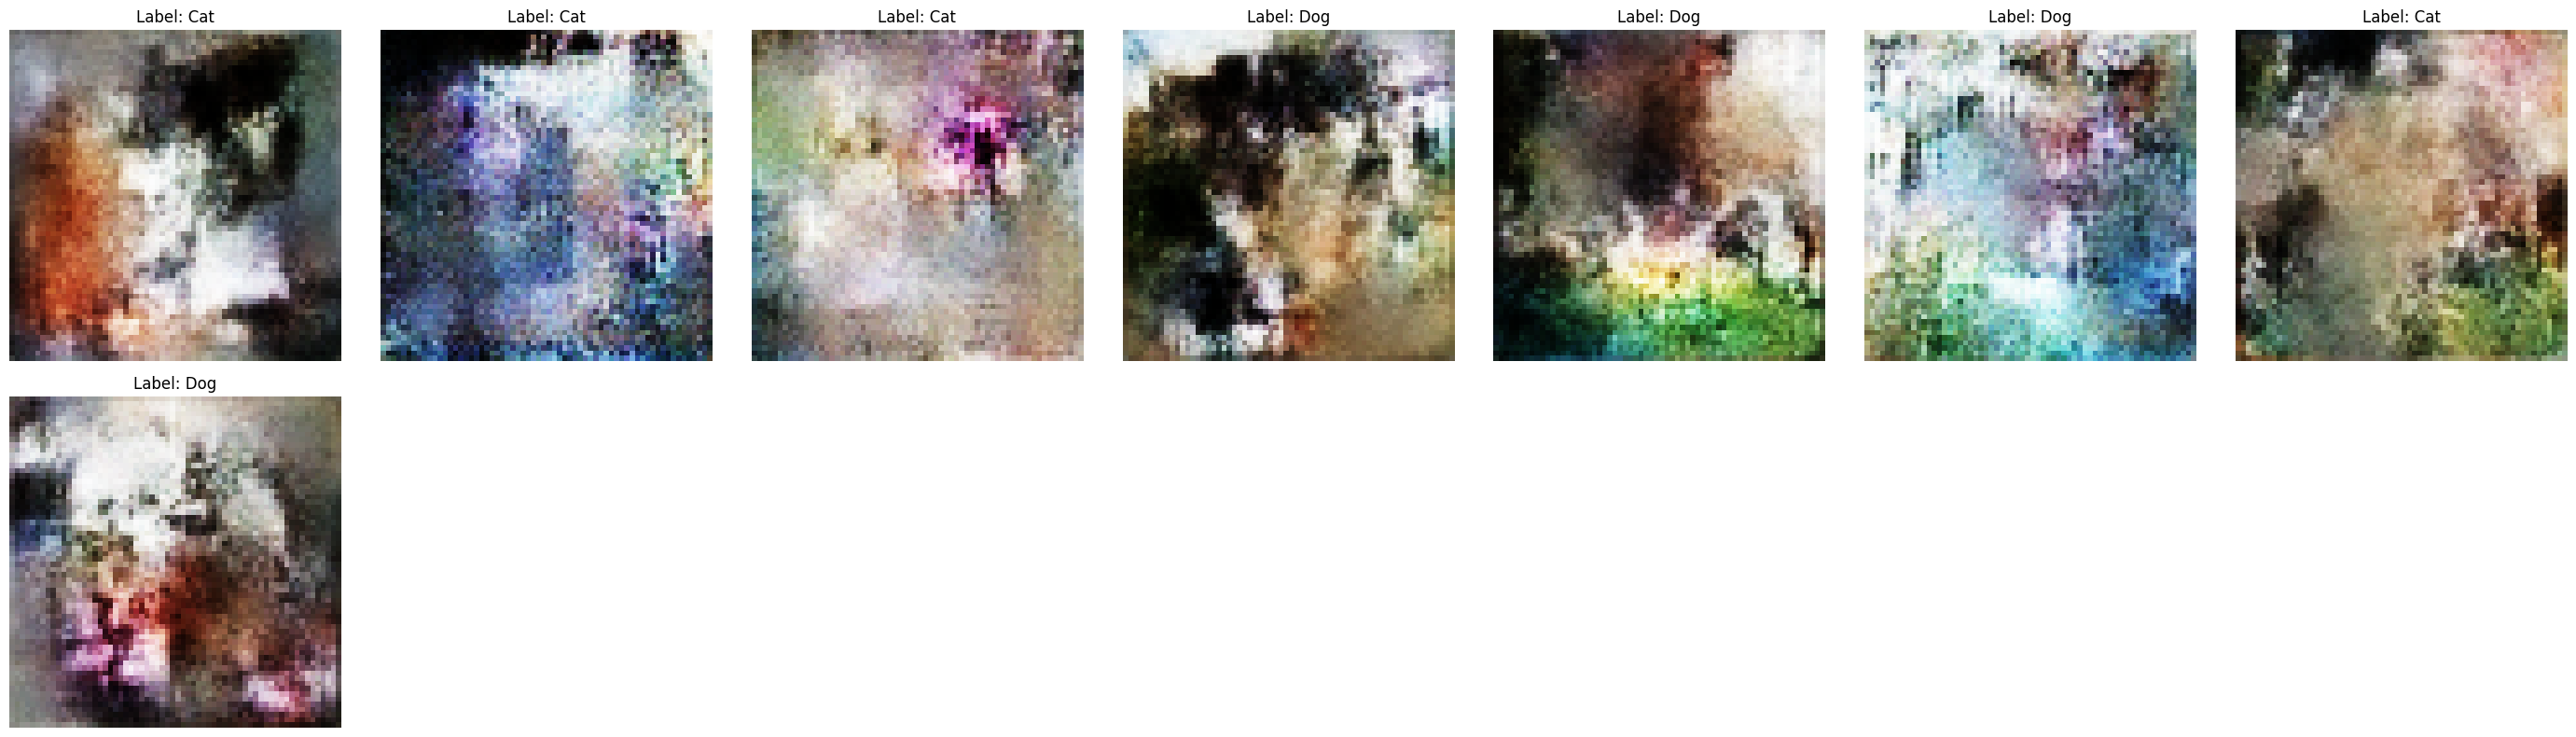

Epoch 31: Gen Loss: 1.0340, Disc Loss: 1.2825
Epoch 32: Gen Loss: 1.0698, Disc Loss: 1.1770
Epoch 32: Gen Loss: 1.0698, Disc Loss: 1.1770
Epoch 33: Gen Loss: 1.0340, Disc Loss: 1.2103
Epoch 33: Gen Loss: 1.0340, Disc Loss: 1.2103
Epoch 34: Gen Loss: 1.0258, Disc Loss: 1.2564
Epoch 34: Gen Loss: 1.0258, Disc Loss: 1.2564
Epoch 35: Gen Loss: 1.0301, Disc Loss: 1.2261
Epoch 35: Gen Loss: 1.0301, Disc Loss: 1.2261
Epoch 36: Gen Loss: 1.0448, Disc Loss: 1.2213
Epoch 36: Gen Loss: 1.0448, Disc Loss: 1.2213
Epoch 37: Gen Loss: 1.0256, Disc Loss: 1.2283
Epoch 37: Gen Loss: 1.0256, Disc Loss: 1.2283
Epoch 38: Gen Loss: 1.0684, Disc Loss: 1.2387
Epoch 38: Gen Loss: 1.0684, Disc Loss: 1.2387
Epoch 39: Gen Loss: 1.0294, Disc Loss: 1.2145
Epoch 39: Gen Loss: 1.0294, Disc Loss: 1.2145
Epoch 40: Gen Loss: 1.1313, Disc Loss: 1.2459
Epoch 40: Gen Loss: 1.1313, Disc Loss: 1.2459


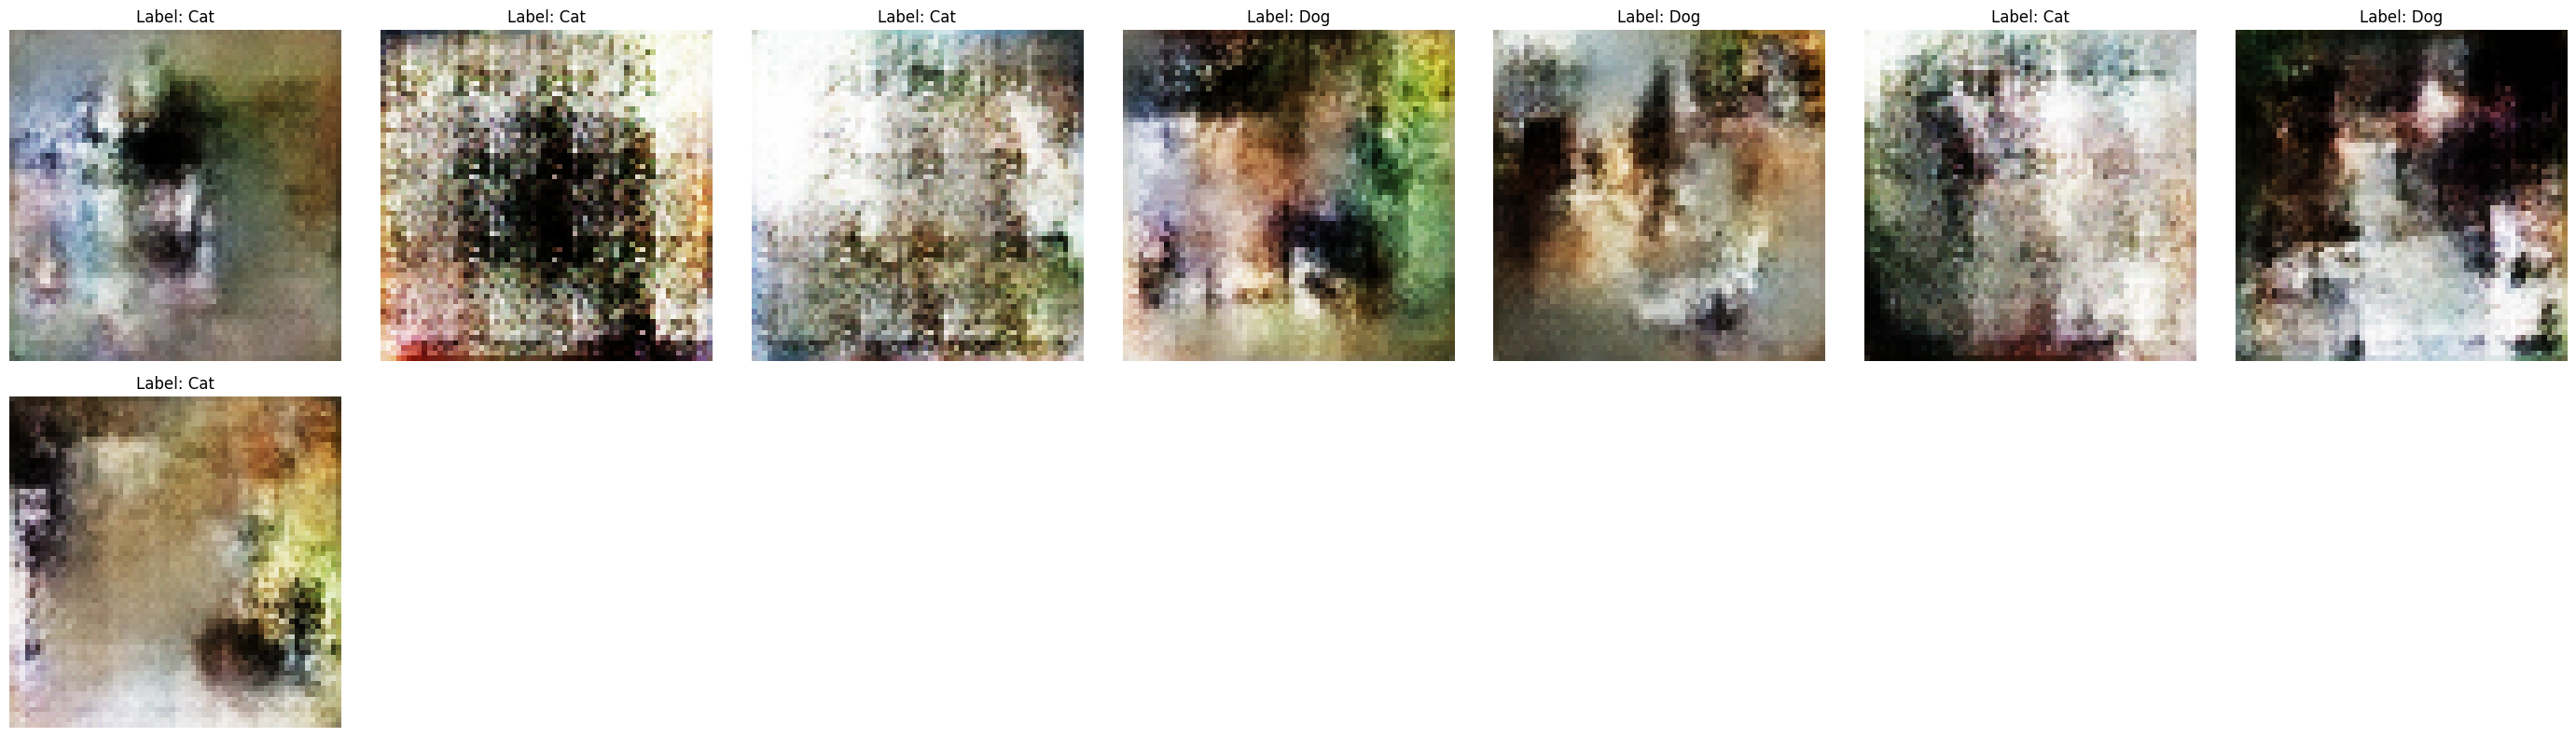

Epoch 41: Gen Loss: 1.1307, Disc Loss: 1.1515
Epoch 42: Gen Loss: 1.0790, Disc Loss: 1.1999
Epoch 42: Gen Loss: 1.0790, Disc Loss: 1.1999
Epoch 43: Gen Loss: 1.0451, Disc Loss: 1.2107
Epoch 43: Gen Loss: 1.0451, Disc Loss: 1.2107
Epoch 44: Gen Loss: 1.0355, Disc Loss: 1.2368
Epoch 44: Gen Loss: 1.0355, Disc Loss: 1.2368
Epoch 45: Gen Loss: 1.0271, Disc Loss: 1.2476
Epoch 45: Gen Loss: 1.0271, Disc Loss: 1.2476
Epoch 46: Gen Loss: 1.0710, Disc Loss: 1.2792
Epoch 46: Gen Loss: 1.0710, Disc Loss: 1.2792
Epoch 47: Gen Loss: 1.1246, Disc Loss: 1.1689
Epoch 47: Gen Loss: 1.1246, Disc Loss: 1.1689
Epoch 48: Gen Loss: 1.1324, Disc Loss: 1.1700
Epoch 48: Gen Loss: 1.1324, Disc Loss: 1.1700
Epoch 49: Gen Loss: 1.0863, Disc Loss: 1.1729
Epoch 49: Gen Loss: 1.0863, Disc Loss: 1.1729
Epoch 50: Gen Loss: 1.0482, Disc Loss: 1.2300
Epoch 50: Gen Loss: 1.0482, Disc Loss: 1.2300


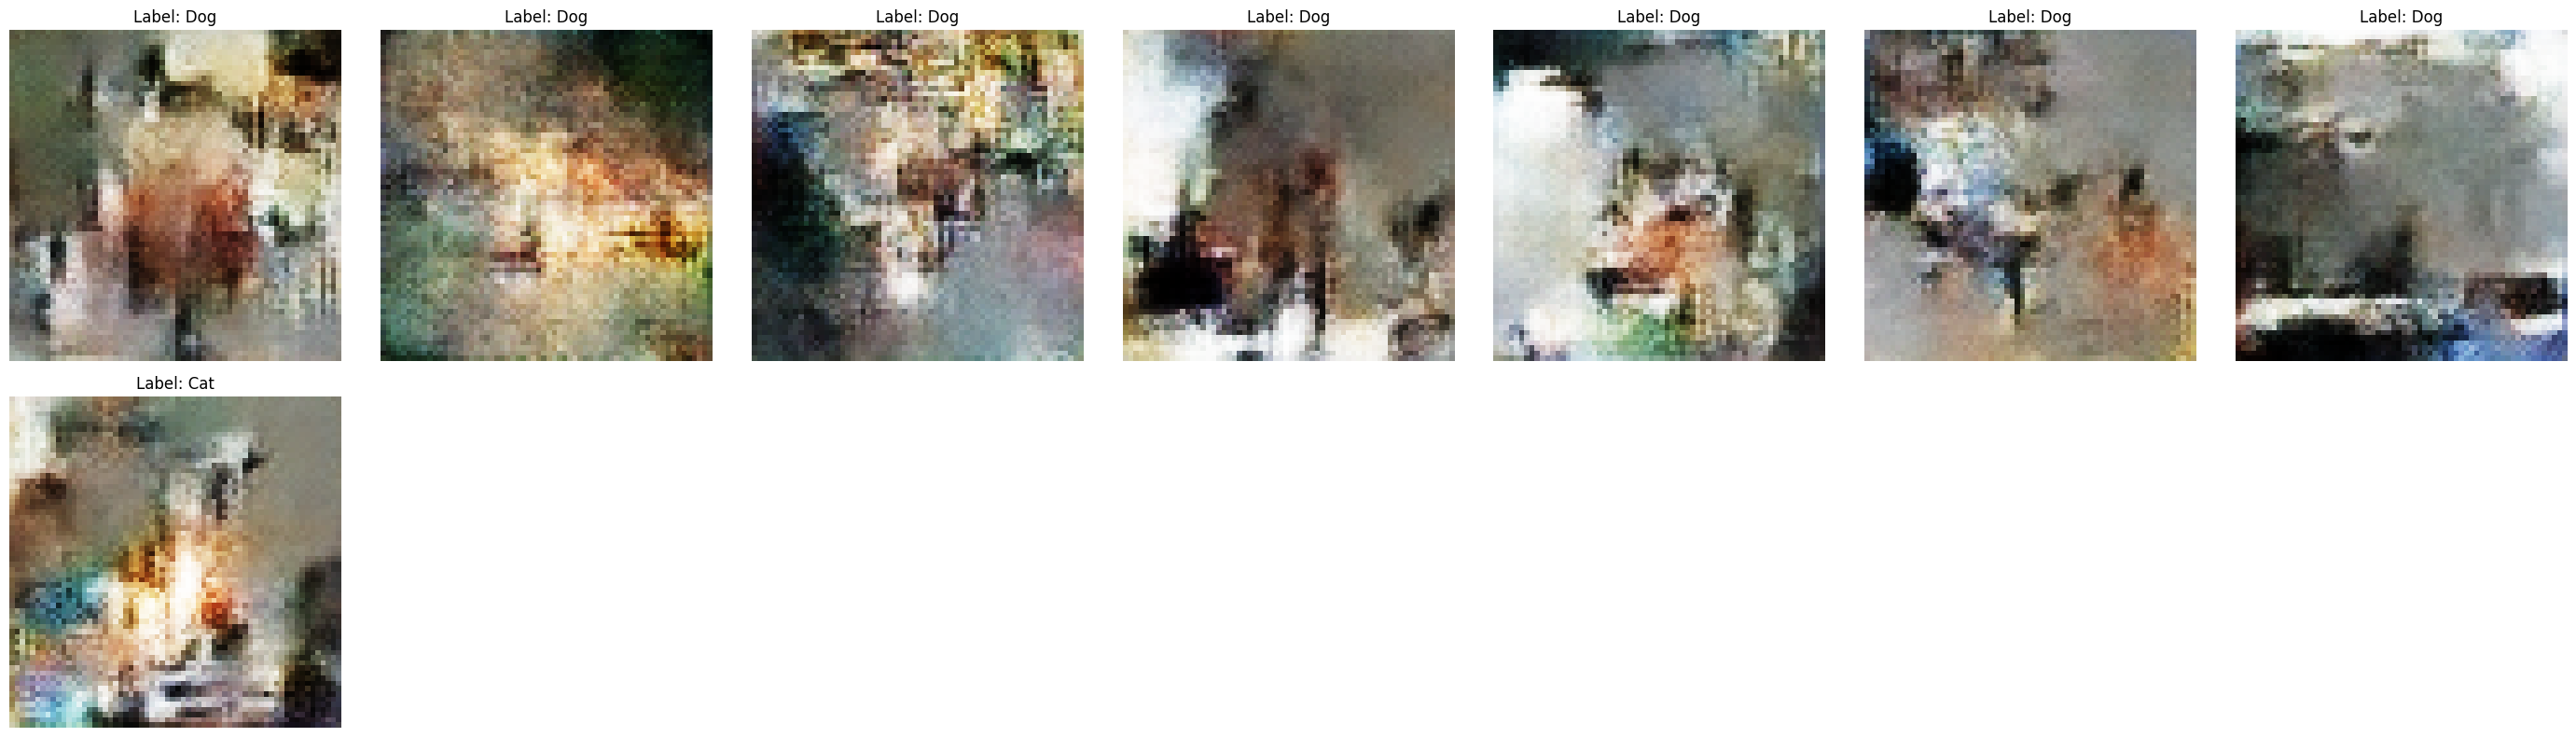

Epoch 51: Gen Loss: 1.0327, Disc Loss: 1.2209
Epoch 52: Gen Loss: 1.0679, Disc Loss: 1.2512
Epoch 52: Gen Loss: 1.0679, Disc Loss: 1.2512
Epoch 53: Gen Loss: 1.0168, Disc Loss: 1.2135
Epoch 53: Gen Loss: 1.0168, Disc Loss: 1.2135
Epoch 54: Gen Loss: 1.0046, Disc Loss: 1.2654
Epoch 54: Gen Loss: 1.0046, Disc Loss: 1.2654
Epoch 55: Gen Loss: 1.0044, Disc Loss: 1.2465
Epoch 55: Gen Loss: 1.0044, Disc Loss: 1.2465
Epoch 56: Gen Loss: 1.0430, Disc Loss: 1.2530
Epoch 56: Gen Loss: 1.0430, Disc Loss: 1.2530
Epoch 57: Gen Loss: 1.0165, Disc Loss: 1.2259
Epoch 57: Gen Loss: 1.0165, Disc Loss: 1.2259
Epoch 58: Gen Loss: 1.0317, Disc Loss: 1.2379
Epoch 58: Gen Loss: 1.0317, Disc Loss: 1.2379
Epoch 59: Gen Loss: 1.0728, Disc Loss: 1.2781
Epoch 59: Gen Loss: 1.0728, Disc Loss: 1.2781
Epoch 60: Gen Loss: 1.3482, Disc Loss: 1.1317
Epoch 60: Gen Loss: 1.3482, Disc Loss: 1.1317


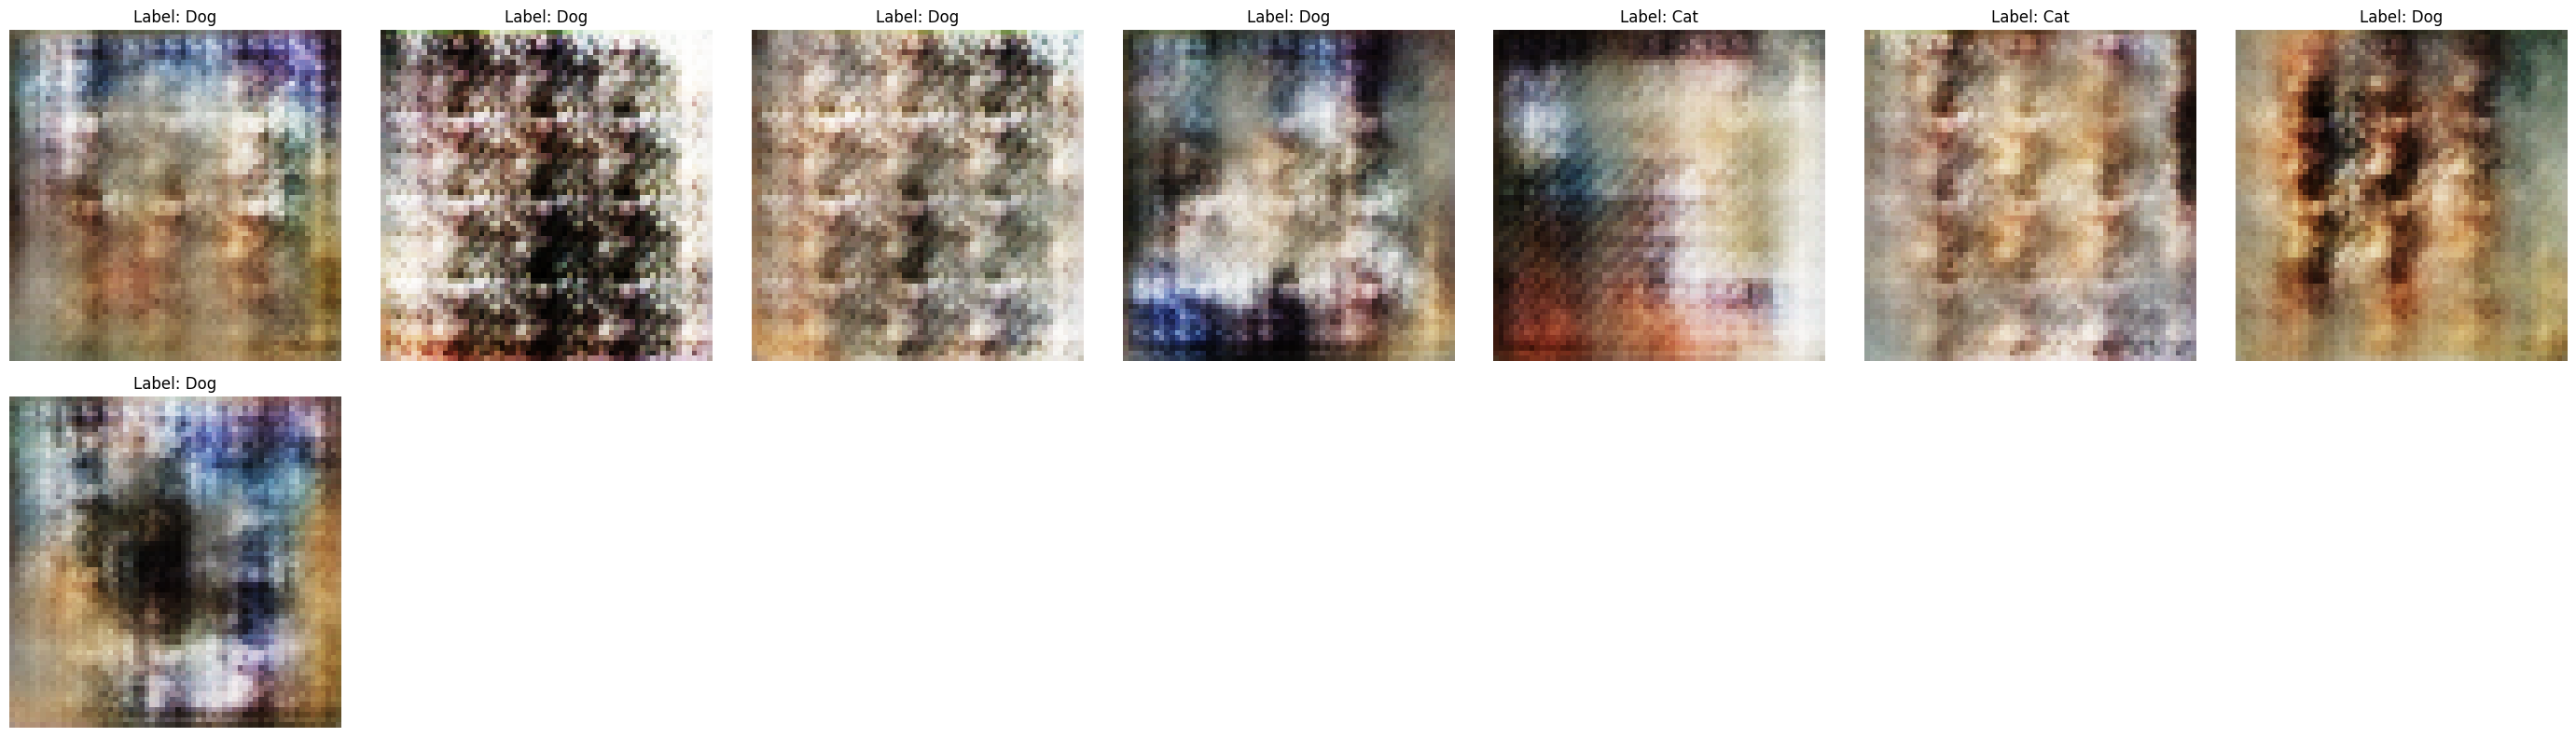

Epoch 61: Gen Loss: 1.3767, Disc Loss: 1.0444
Epoch 62: Gen Loss: 1.4339, Disc Loss: 1.0745
Epoch 62: Gen Loss: 1.4339, Disc Loss: 1.0745
Epoch 63: Gen Loss: 1.4329, Disc Loss: 1.0452
Epoch 63: Gen Loss: 1.4329, Disc Loss: 1.0452
Epoch 64: Gen Loss: 1.3673, Disc Loss: 1.0392
Epoch 64: Gen Loss: 1.3673, Disc Loss: 1.0392
Epoch 65: Gen Loss: 1.3271, Disc Loss: 1.0794
Epoch 65: Gen Loss: 1.3271, Disc Loss: 1.0794
Epoch 66: Gen Loss: 1.1978, Disc Loss: 1.1422
Epoch 66: Gen Loss: 1.1978, Disc Loss: 1.1422
Epoch 67: Gen Loss: 1.0897, Disc Loss: 1.1707
Epoch 67: Gen Loss: 1.0897, Disc Loss: 1.1707
Epoch 68: Gen Loss: 1.0617, Disc Loss: 1.2385
Epoch 68: Gen Loss: 1.0617, Disc Loss: 1.2385
Epoch 69: Gen Loss: 1.0338, Disc Loss: 1.2315
Epoch 69: Gen Loss: 1.0338, Disc Loss: 1.2315
Epoch 70: Gen Loss: 1.0483, Disc Loss: 1.2154
Epoch 70: Gen Loss: 1.0483, Disc Loss: 1.2154


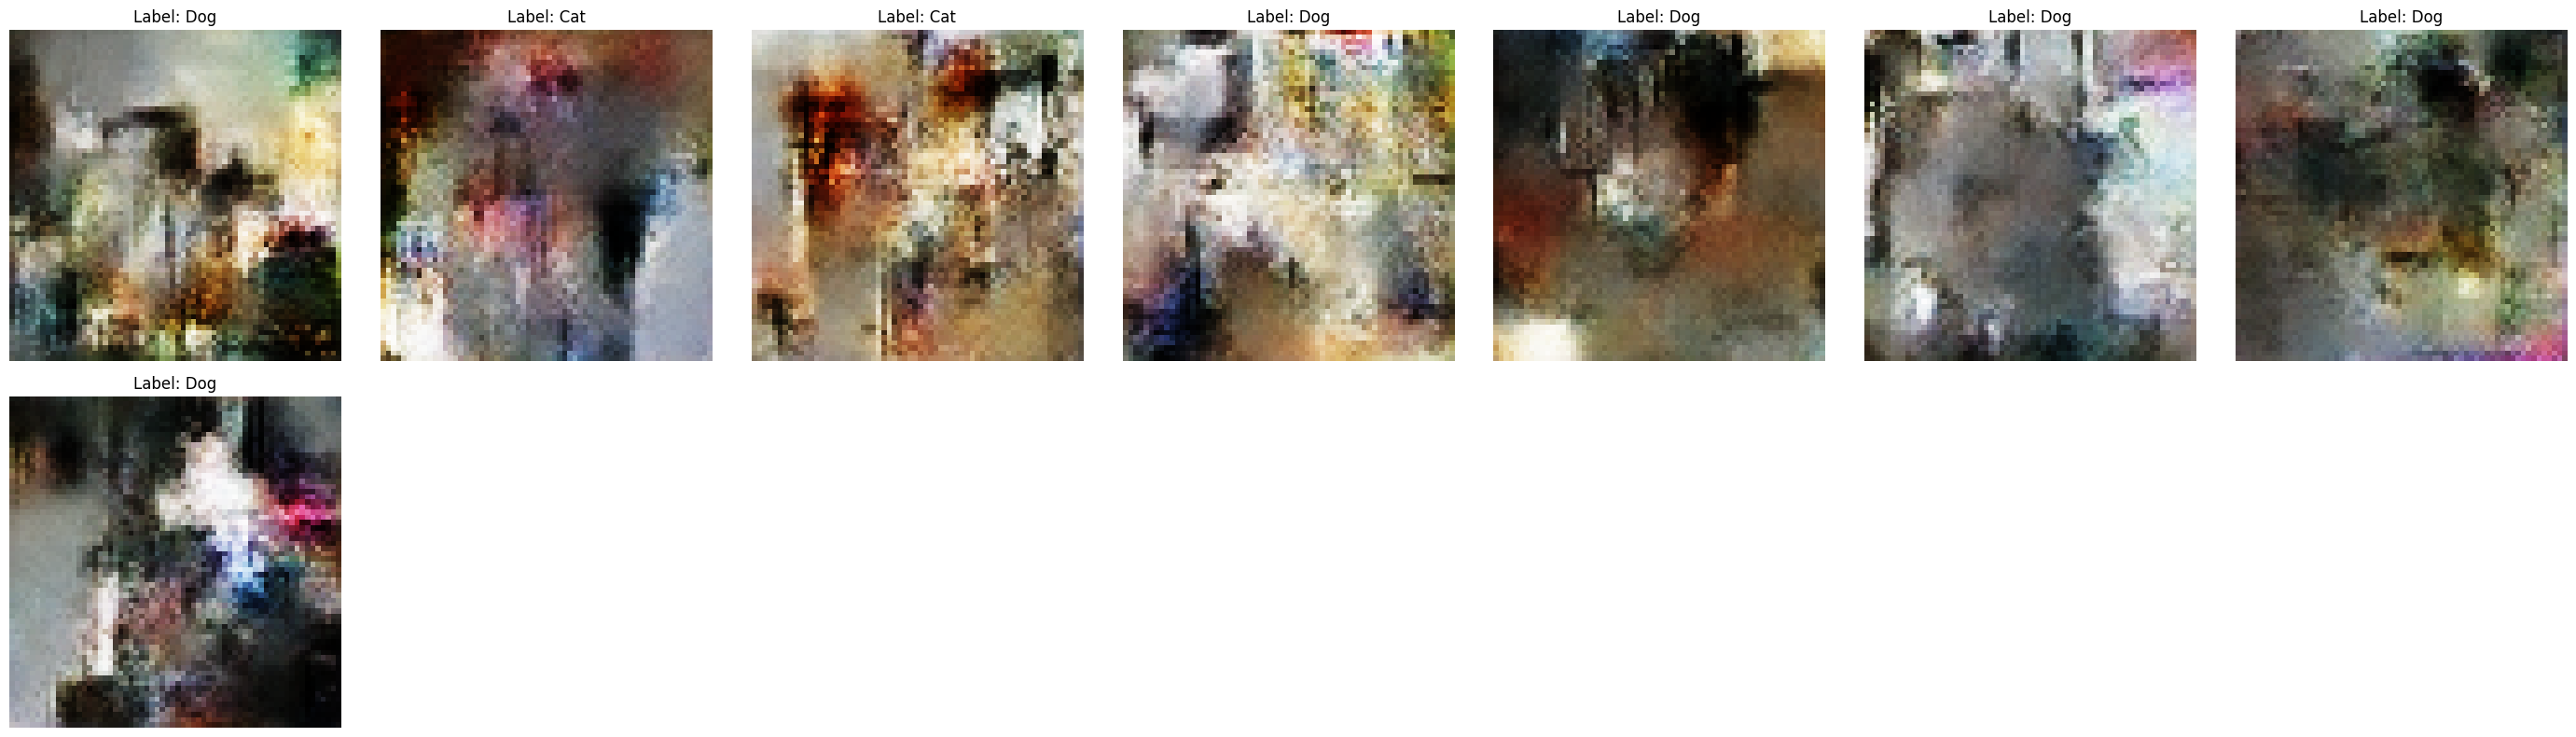

Epoch 71: Gen Loss: 1.0875, Disc Loss: 1.2566
Epoch 72: Gen Loss: 1.0390, Disc Loss: 1.2153
Epoch 72: Gen Loss: 1.0390, Disc Loss: 1.2153
Epoch 73: Gen Loss: 1.0406, Disc Loss: 1.2517
Epoch 73: Gen Loss: 1.0406, Disc Loss: 1.2517
Epoch 74: Gen Loss: 1.0319, Disc Loss: 1.2237
Epoch 74: Gen Loss: 1.0319, Disc Loss: 1.2237
Epoch 75: Gen Loss: 1.0357, Disc Loss: 1.2681
Epoch 75: Gen Loss: 1.0357, Disc Loss: 1.2681
Epoch 76: Gen Loss: 0.9983, Disc Loss: 1.2346
Epoch 76: Gen Loss: 0.9983, Disc Loss: 1.2346
Epoch 77: Gen Loss: 1.0131, Disc Loss: 1.2495
Epoch 77: Gen Loss: 1.0131, Disc Loss: 1.2495
Epoch 78: Gen Loss: 1.0224, Disc Loss: 1.2268
Epoch 78: Gen Loss: 1.0224, Disc Loss: 1.2268
Epoch 79: Gen Loss: 1.0185, Disc Loss: 1.2581
Epoch 79: Gen Loss: 1.0185, Disc Loss: 1.2581
Epoch 80: Gen Loss: 1.0148, Disc Loss: 1.2332
Epoch 80: Gen Loss: 1.0148, Disc Loss: 1.2332


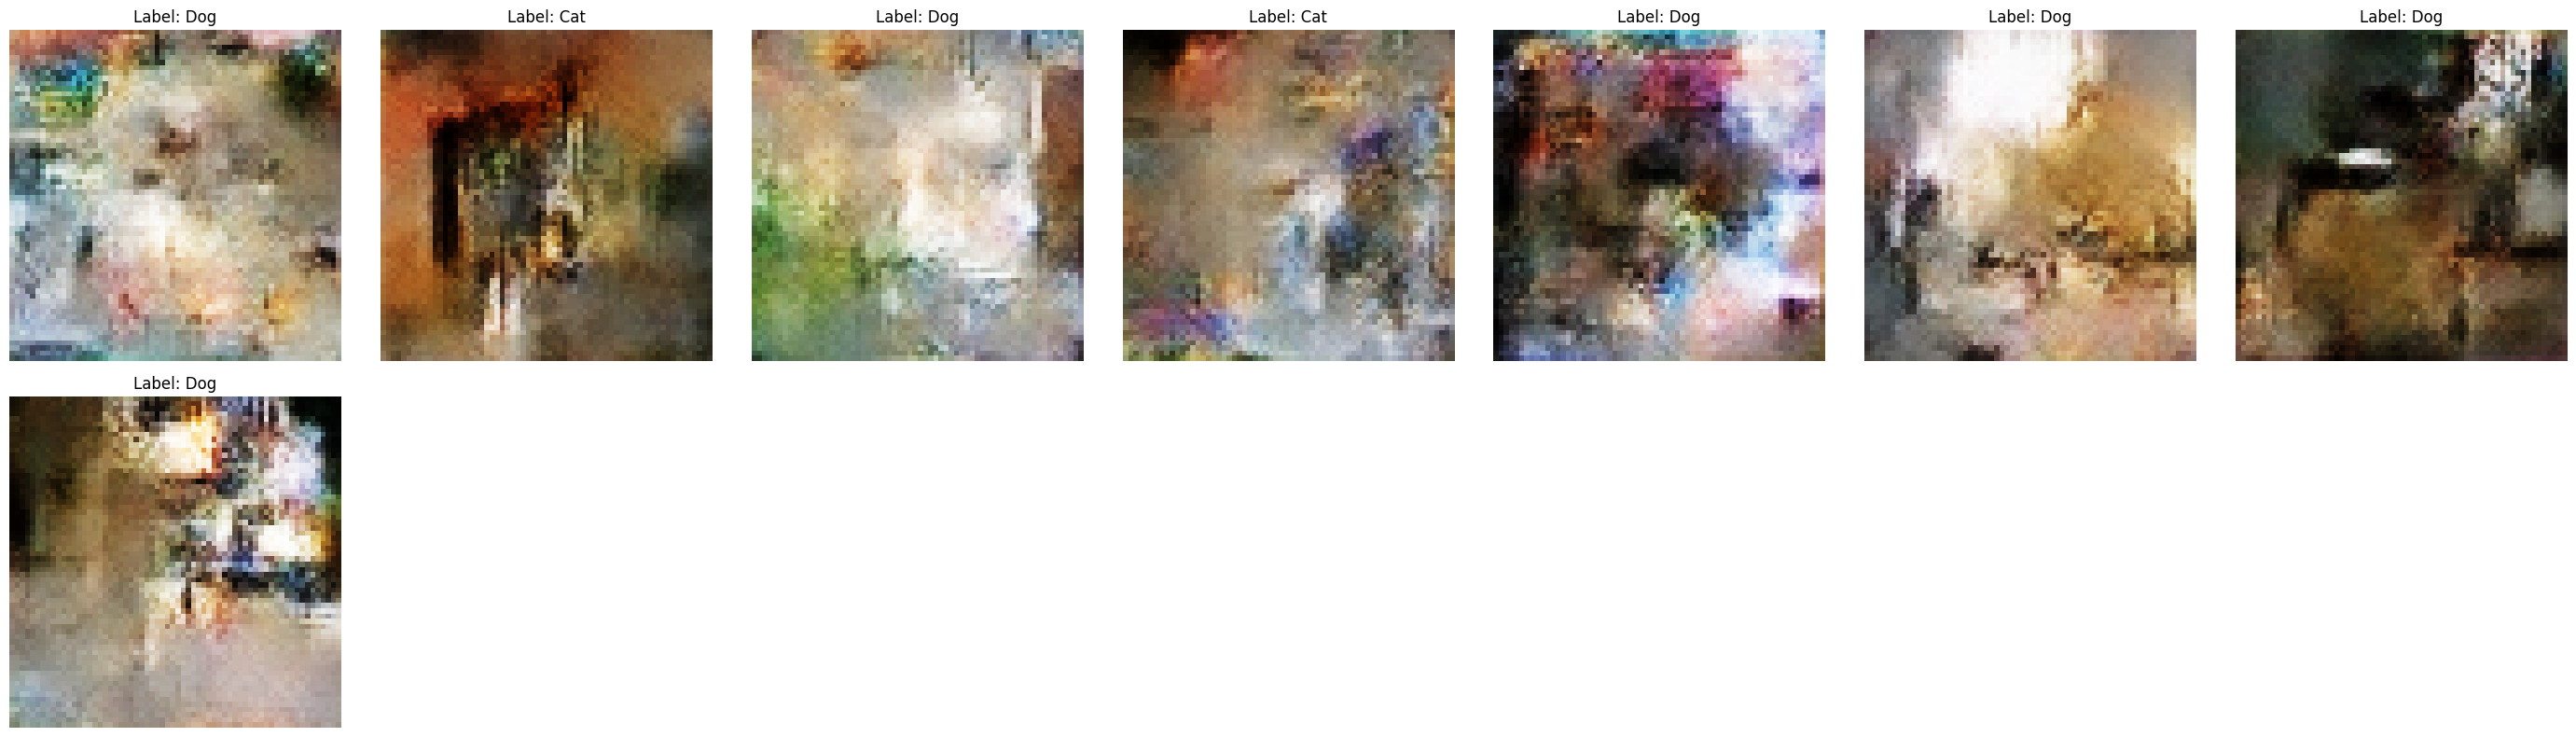

Epoch 81: Gen Loss: 1.2227, Disc Loss: 1.2200
Epoch 82: Gen Loss: 1.5318, Disc Loss: 1.0198
Epoch 82: Gen Loss: 1.5318, Disc Loss: 1.0198
Epoch 83: Gen Loss: 1.5326, Disc Loss: 0.9802
Epoch 83: Gen Loss: 1.5326, Disc Loss: 0.9802
Epoch 84: Gen Loss: 1.5656, Disc Loss: 0.9726
Epoch 84: Gen Loss: 1.5656, Disc Loss: 0.9726
Epoch 85: Gen Loss: 1.5201, Disc Loss: 0.9690
Epoch 85: Gen Loss: 1.5201, Disc Loss: 0.9690
Epoch 86: Gen Loss: 1.4967, Disc Loss: 1.0072
Epoch 86: Gen Loss: 1.4967, Disc Loss: 1.0072
Epoch 87: Gen Loss: 1.3724, Disc Loss: 1.0790
Epoch 87: Gen Loss: 1.3724, Disc Loss: 1.0790
Epoch 88: Gen Loss: 1.2313, Disc Loss: 1.1220
Epoch 88: Gen Loss: 1.2313, Disc Loss: 1.1220
Epoch 89: Gen Loss: 1.1393, Disc Loss: 1.1497
Epoch 89: Gen Loss: 1.1393, Disc Loss: 1.1497
Epoch 90: Gen Loss: 1.1197, Disc Loss: 1.2198
Epoch 90: Gen Loss: 1.1197, Disc Loss: 1.2198


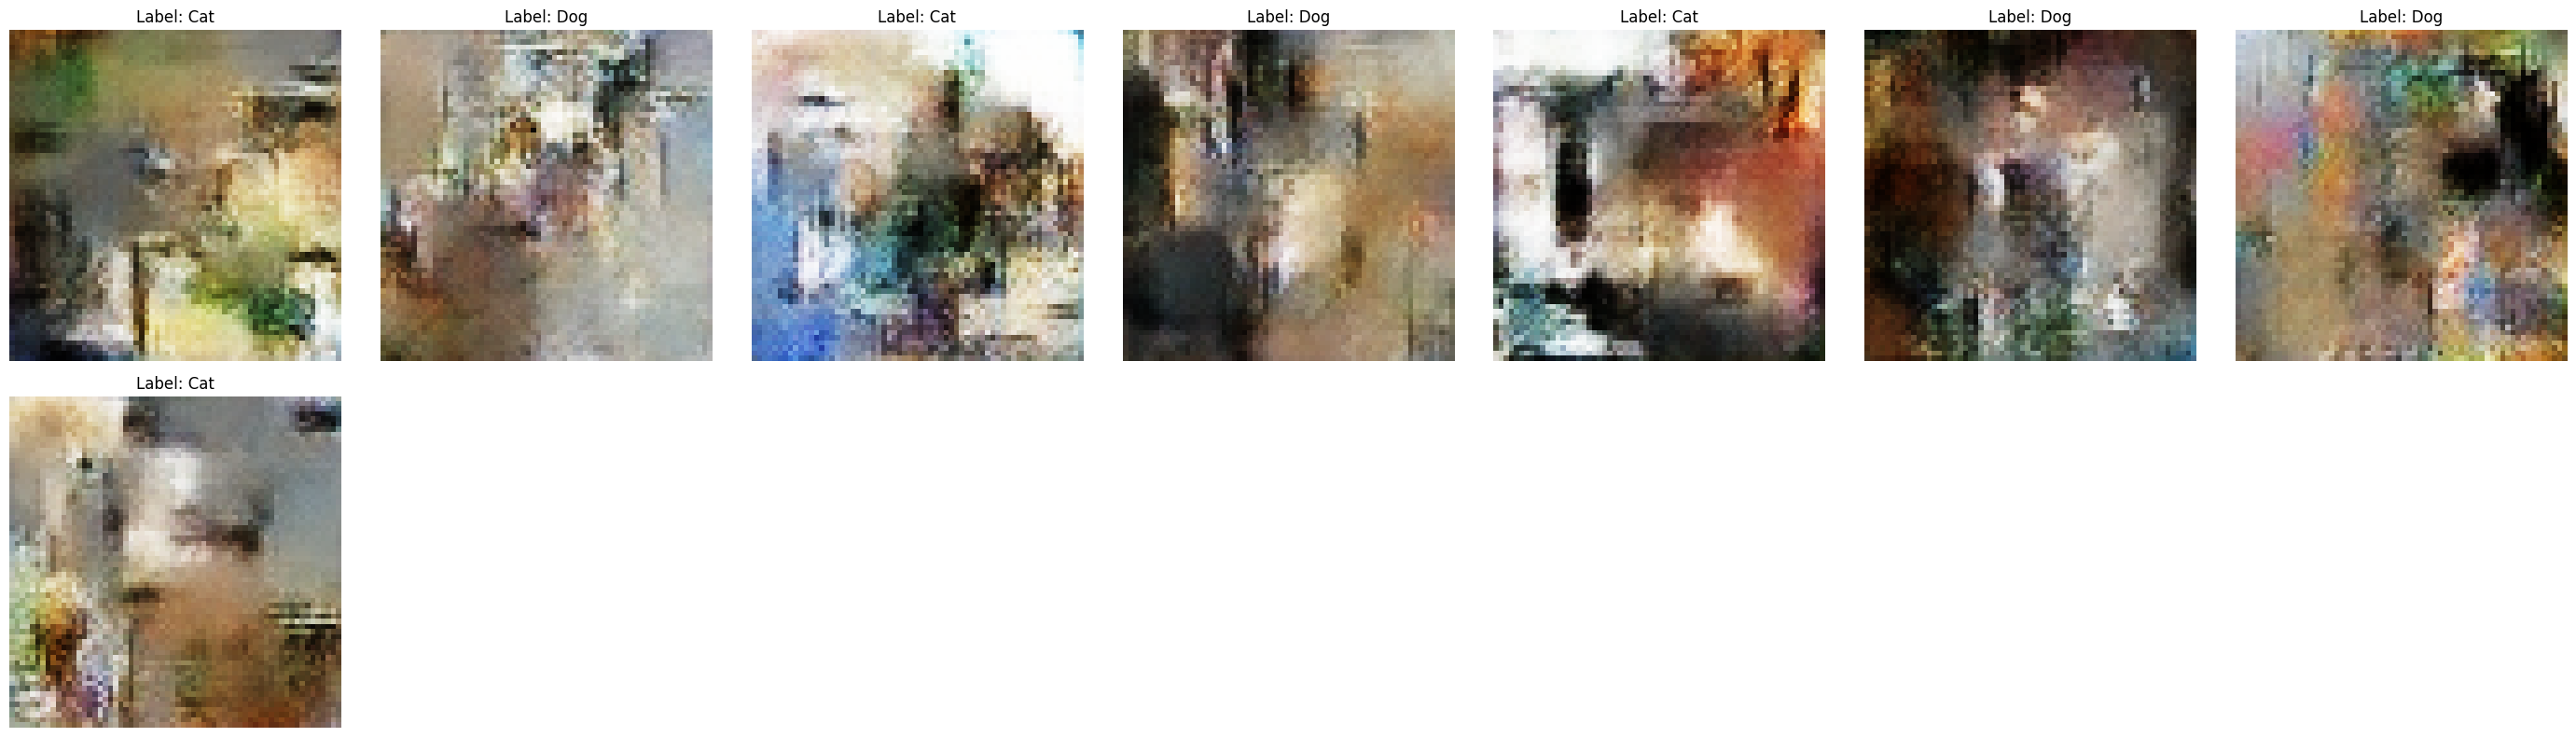

Epoch 91: Gen Loss: 1.0898, Disc Loss: 1.1834
Epoch 92: Gen Loss: 1.0755, Disc Loss: 1.2234
Epoch 92: Gen Loss: 1.0755, Disc Loss: 1.2234
Epoch 93: Gen Loss: 1.0785, Disc Loss: 1.2262
Epoch 93: Gen Loss: 1.0785, Disc Loss: 1.2262
Epoch 94: Gen Loss: 1.0775, Disc Loss: 1.2184
Epoch 94: Gen Loss: 1.0775, Disc Loss: 1.2184
Epoch 95: Gen Loss: 1.0602, Disc Loss: 1.1948
Epoch 95: Gen Loss: 1.0602, Disc Loss: 1.1948
Epoch 96: Gen Loss: 1.0674, Disc Loss: 1.2212
Epoch 96: Gen Loss: 1.0674, Disc Loss: 1.2212
Epoch 97: Gen Loss: 1.0513, Disc Loss: 1.2338
Epoch 97: Gen Loss: 1.0513, Disc Loss: 1.2338
Epoch 98: Gen Loss: 1.0555, Disc Loss: 1.2107
Epoch 98: Gen Loss: 1.0555, Disc Loss: 1.2107
Epoch 99: Gen Loss: 1.0370, Disc Loss: 1.2260
Epoch 99: Gen Loss: 1.0370, Disc Loss: 1.2260
Epoch 100: Gen Loss: 1.0346, Disc Loss: 1.2568
Epoch 100: Gen Loss: 1.0346, Disc Loss: 1.2568


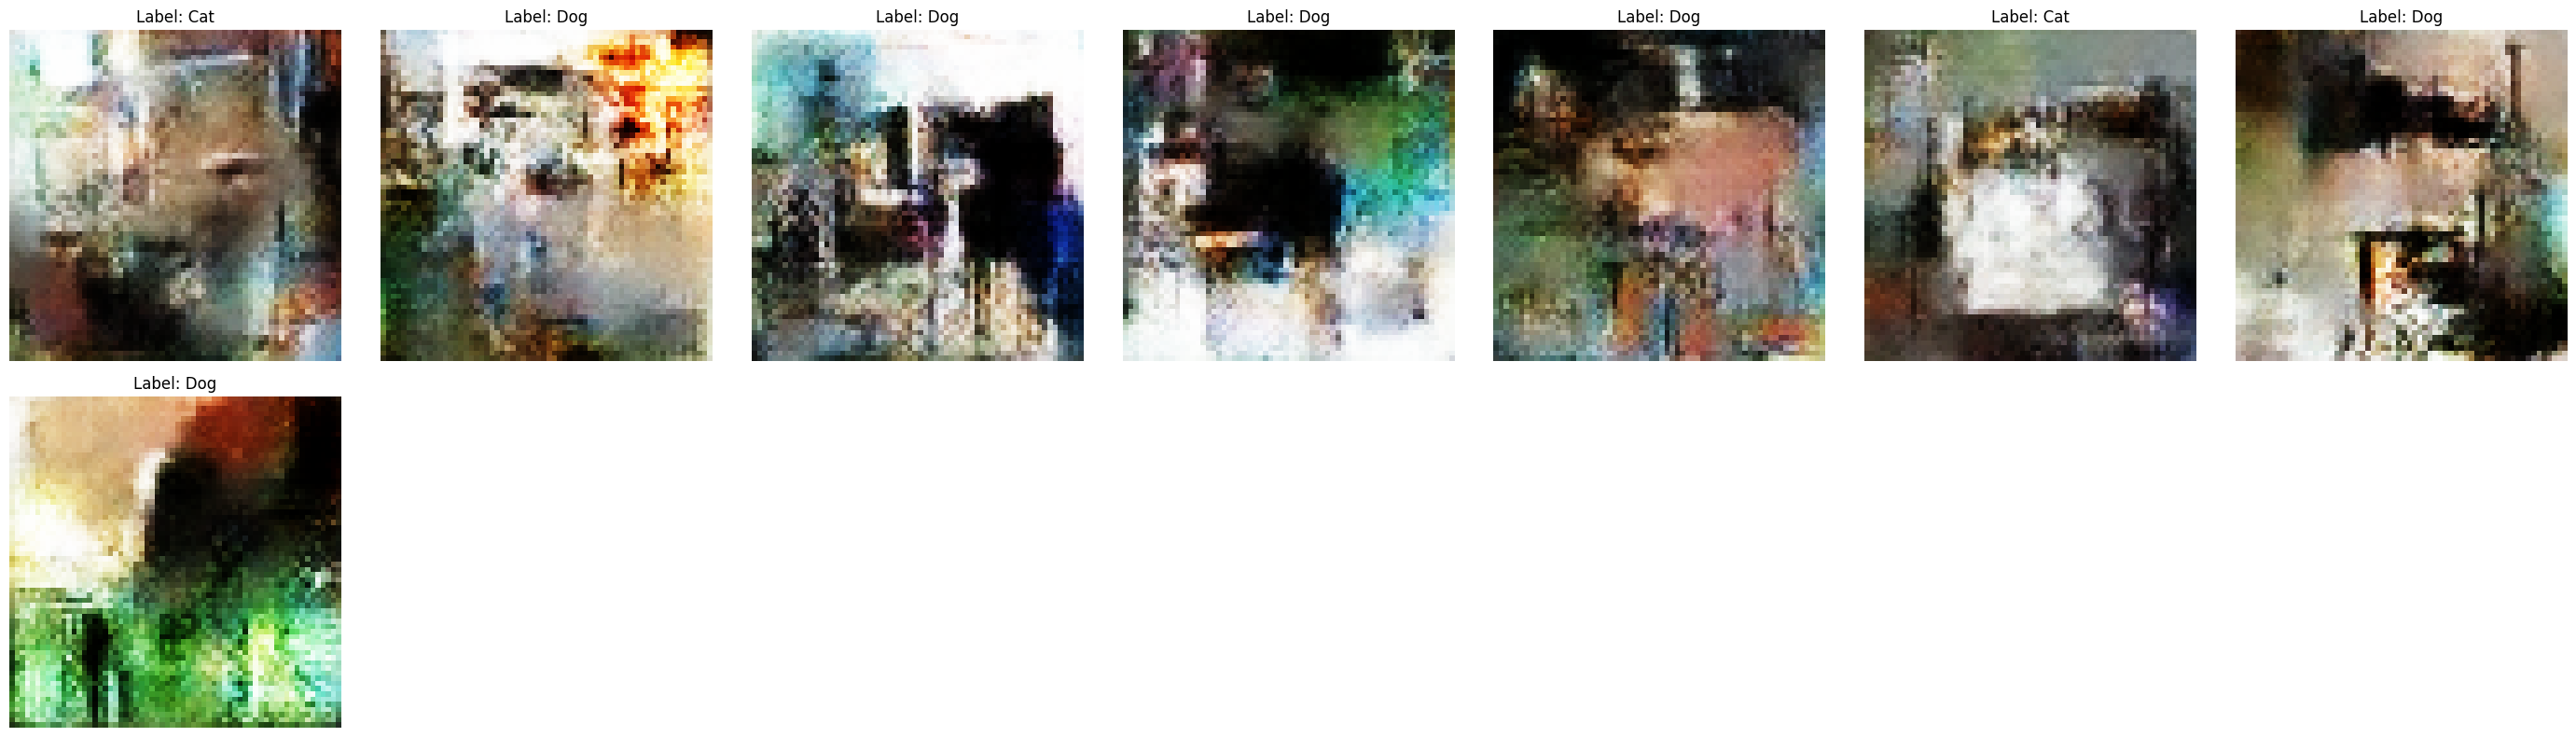

Epoch 101: Gen Loss: 1.0284, Disc Loss: 1.2292
Epoch 102: Gen Loss: 1.0375, Disc Loss: 1.2431
Epoch 102: Gen Loss: 1.0375, Disc Loss: 1.2431
Epoch 103: Gen Loss: 1.0285, Disc Loss: 1.2471
Epoch 103: Gen Loss: 1.0285, Disc Loss: 1.2471
Epoch 104: Gen Loss: 1.0256, Disc Loss: 1.2311
Epoch 104: Gen Loss: 1.0256, Disc Loss: 1.2311
Epoch 105: Gen Loss: 1.0507, Disc Loss: 1.2592
Epoch 105: Gen Loss: 1.0507, Disc Loss: 1.2592
Epoch 106: Gen Loss: 1.0272, Disc Loss: 1.2248
Epoch 106: Gen Loss: 1.0272, Disc Loss: 1.2248
Epoch 107: Gen Loss: 1.0275, Disc Loss: 1.2331
Epoch 107: Gen Loss: 1.0275, Disc Loss: 1.2331
Epoch 108: Gen Loss: 1.0186, Disc Loss: 1.2439
Epoch 108: Gen Loss: 1.0186, Disc Loss: 1.2439
Epoch 109: Gen Loss: 1.0294, Disc Loss: 1.2361
Epoch 109: Gen Loss: 1.0294, Disc Loss: 1.2361
Epoch 110: Gen Loss: 1.0192, Disc Loss: 1.2373
Epoch 110: Gen Loss: 1.0192, Disc Loss: 1.2373


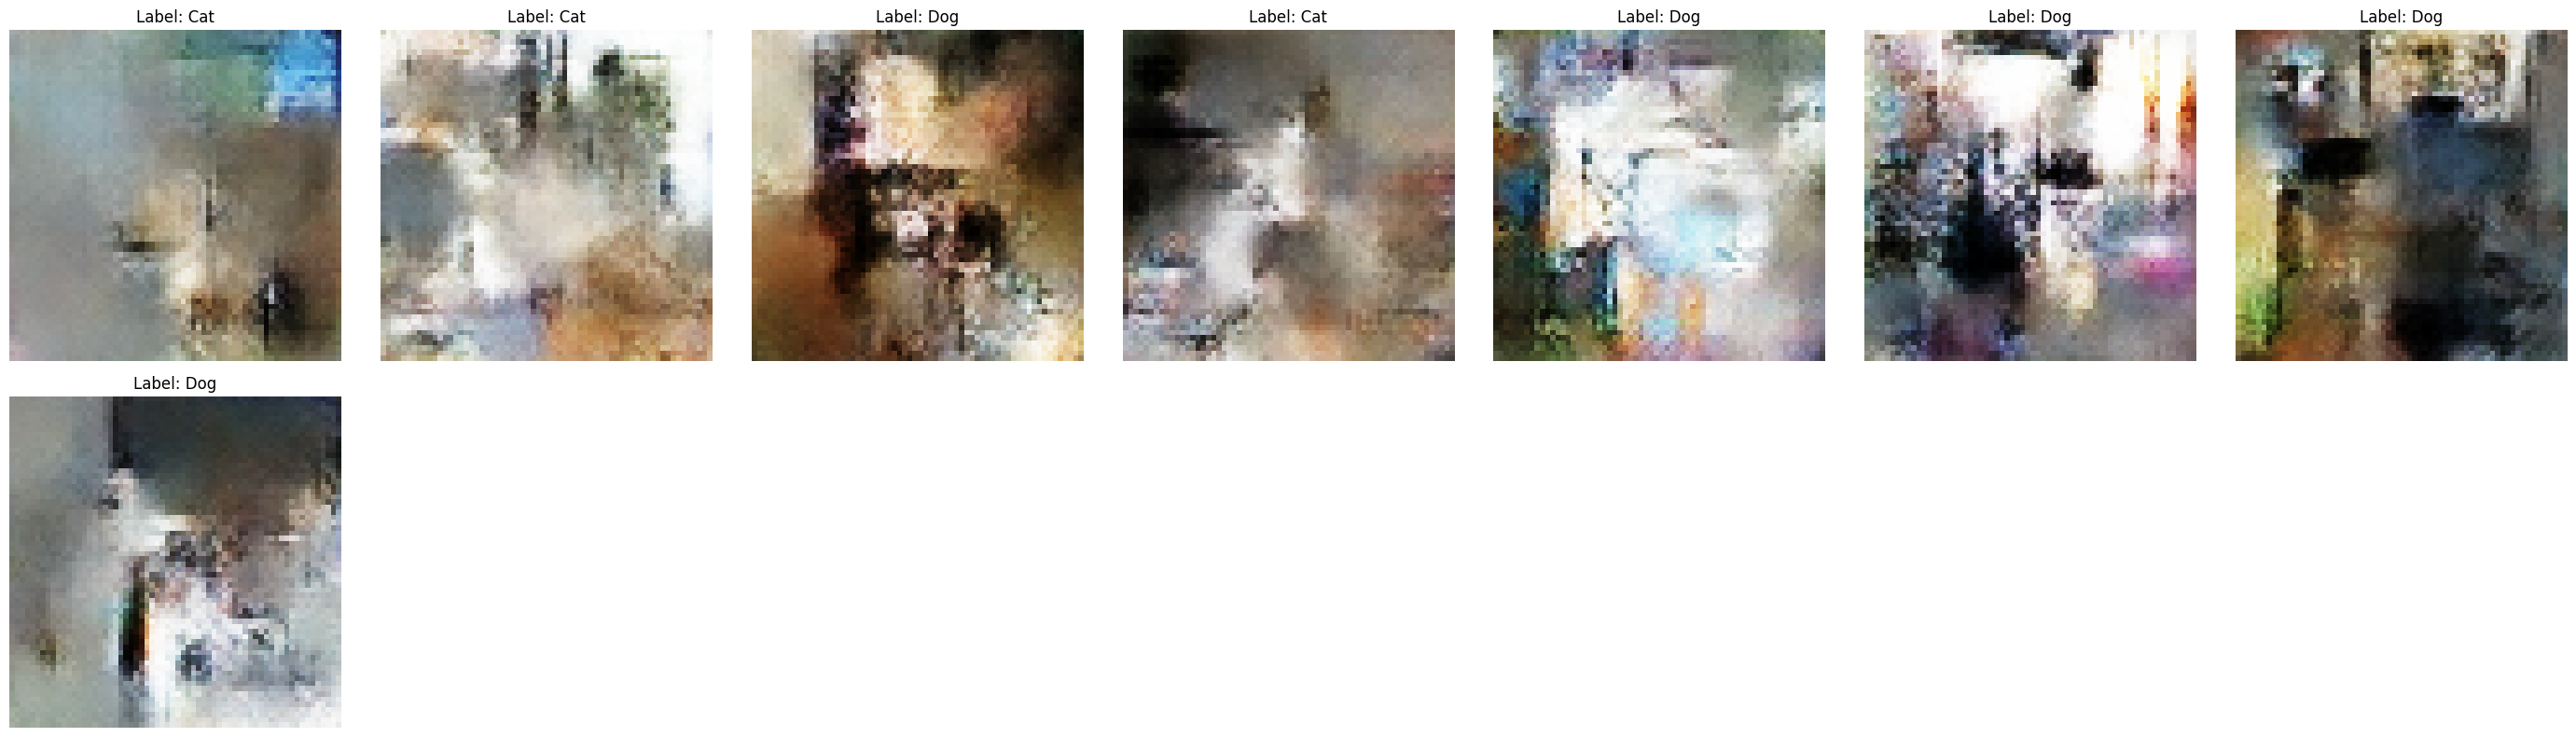

Epoch 111: Gen Loss: 1.0147, Disc Loss: 1.2492
Epoch 112: Gen Loss: 1.0114, Disc Loss: 1.2545
Epoch 112: Gen Loss: 1.0114, Disc Loss: 1.2545
Epoch 113: Gen Loss: 1.0062, Disc Loss: 1.2513
Epoch 113: Gen Loss: 1.0062, Disc Loss: 1.2513
Epoch 114: Gen Loss: 1.0068, Disc Loss: 1.2551
Epoch 114: Gen Loss: 1.0068, Disc Loss: 1.2551
Epoch 115: Gen Loss: 1.0179, Disc Loss: 1.2446
Epoch 115: Gen Loss: 1.0179, Disc Loss: 1.2446
Epoch 116: Gen Loss: 1.0180, Disc Loss: 1.2617
Epoch 116: Gen Loss: 1.0180, Disc Loss: 1.2617
Epoch 117: Gen Loss: 1.0175, Disc Loss: 1.2601
Epoch 117: Gen Loss: 1.0175, Disc Loss: 1.2601
Epoch 118: Gen Loss: 1.0032, Disc Loss: 1.2395
Epoch 118: Gen Loss: 1.0032, Disc Loss: 1.2395
Epoch 119: Gen Loss: 1.0076, Disc Loss: 1.2509
Epoch 119: Gen Loss: 1.0076, Disc Loss: 1.2509
Epoch 120: Gen Loss: 1.0213, Disc Loss: 1.2375
Epoch 120: Gen Loss: 1.0213, Disc Loss: 1.2375


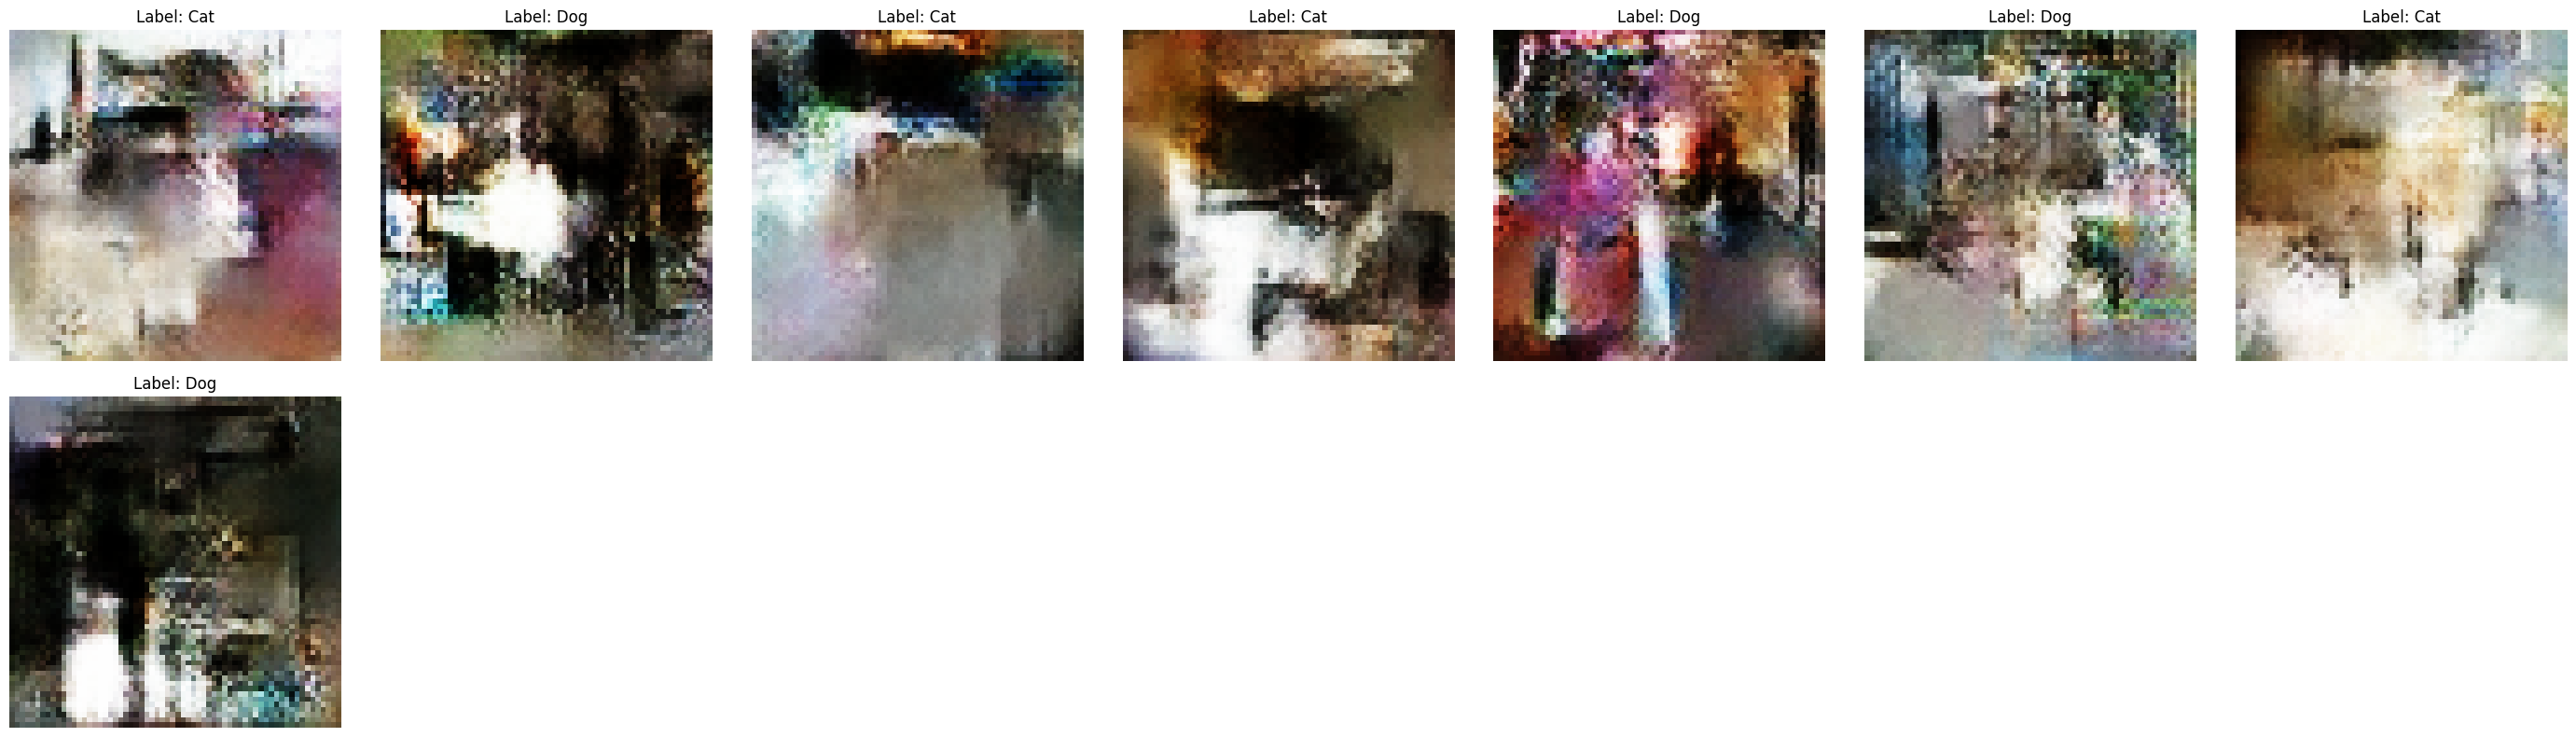

Epoch 121: Gen Loss: 1.0278, Disc Loss: 1.2394
Epoch 122: Gen Loss: 1.0111, Disc Loss: 1.2569
Epoch 122: Gen Loss: 1.0111, Disc Loss: 1.2569
Epoch 123: Gen Loss: 1.0005, Disc Loss: 1.2488
Epoch 123: Gen Loss: 1.0005, Disc Loss: 1.2488
Epoch 124: Gen Loss: 1.0163, Disc Loss: 1.2497
Epoch 124: Gen Loss: 1.0163, Disc Loss: 1.2497
Epoch 125: Gen Loss: 1.2230, Disc Loss: 1.2605
Epoch 125: Gen Loss: 1.2230, Disc Loss: 1.2605
Epoch 126: Gen Loss: 1.6359, Disc Loss: 1.0008
Epoch 126: Gen Loss: 1.6359, Disc Loss: 1.0008
Epoch 127: Gen Loss: 1.6388, Disc Loss: 0.9573
Epoch 127: Gen Loss: 1.6388, Disc Loss: 0.9573
Epoch 128: Gen Loss: 1.6190, Disc Loss: 0.9491
Epoch 128: Gen Loss: 1.6190, Disc Loss: 0.9491
Epoch 129: Gen Loss: 1.6044, Disc Loss: 0.9375
Epoch 129: Gen Loss: 1.6044, Disc Loss: 0.9375
Epoch 130: Gen Loss: 1.5845, Disc Loss: 0.9584
Epoch 130: Gen Loss: 1.5845, Disc Loss: 0.9584


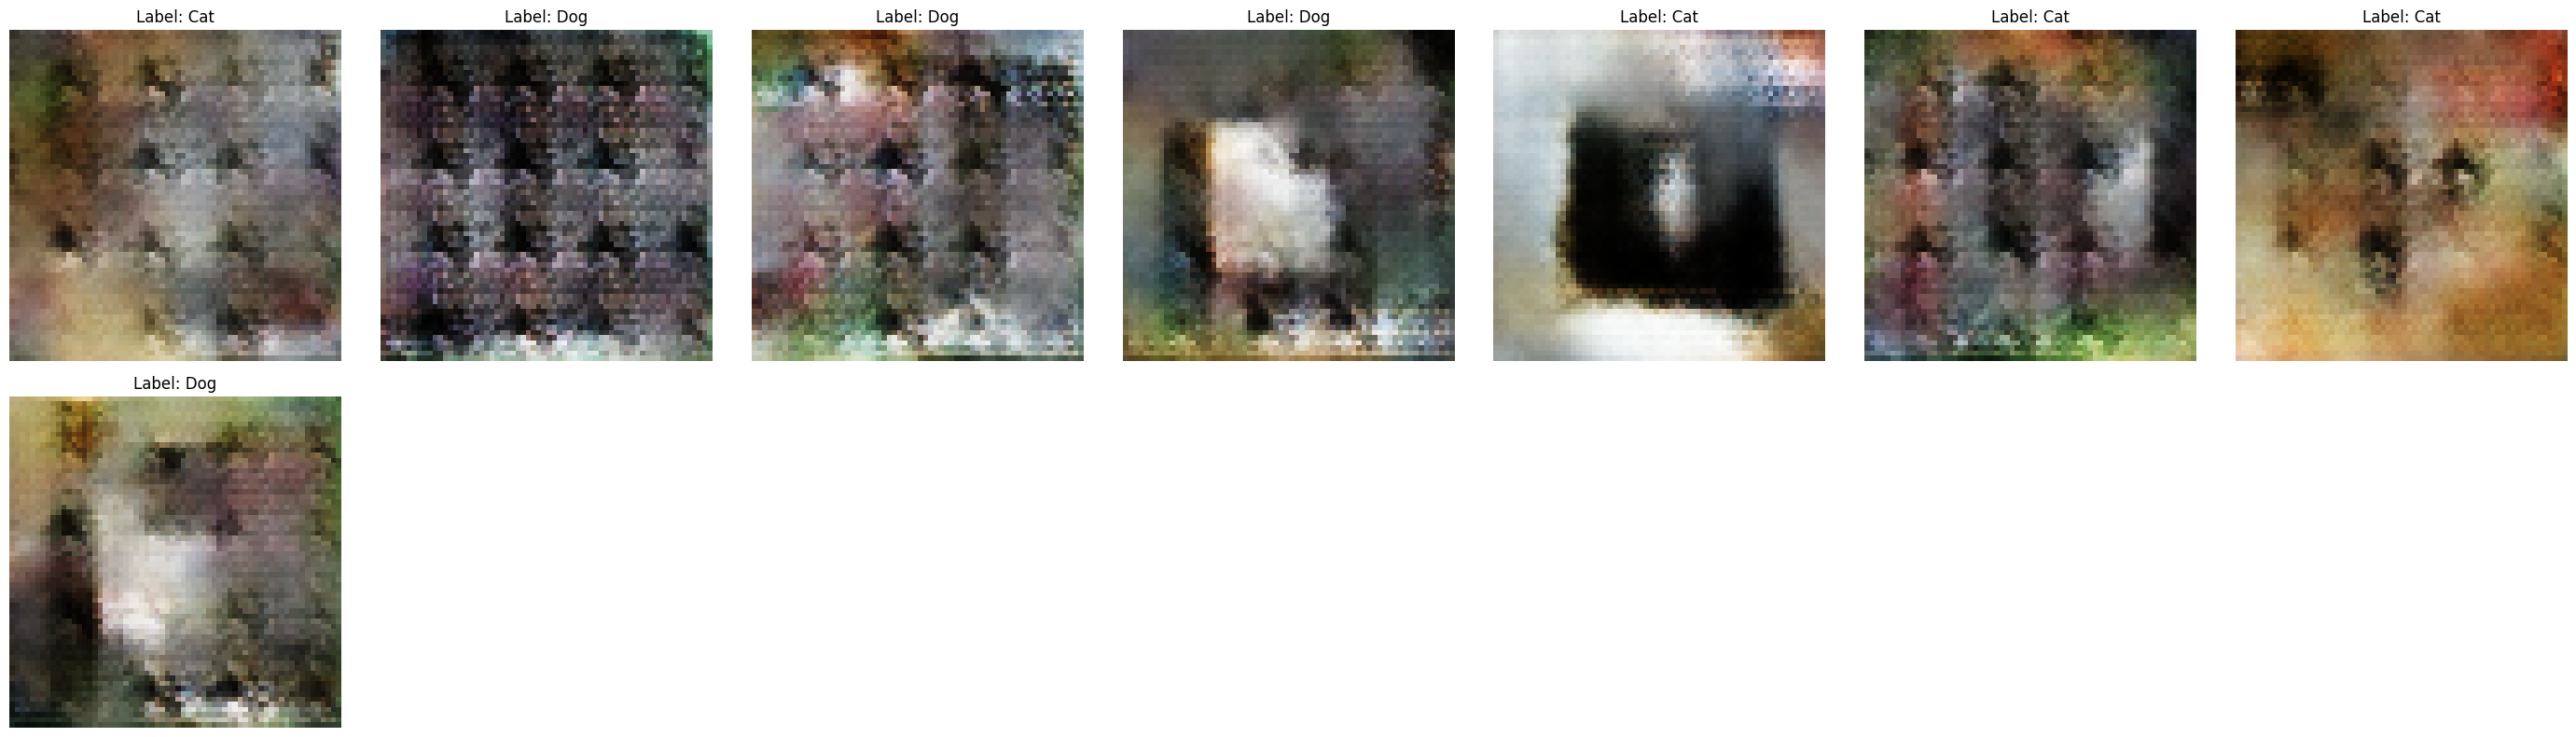

Epoch 131: Gen Loss: 1.4704, Disc Loss: 0.9969
Epoch 132: Gen Loss: 1.3215, Disc Loss: 1.0689
Epoch 132: Gen Loss: 1.3215, Disc Loss: 1.0689
Epoch 133: Gen Loss: 1.1547, Disc Loss: 1.1416
Epoch 133: Gen Loss: 1.1547, Disc Loss: 1.1416
Epoch 134: Gen Loss: 1.1486, Disc Loss: 1.1826
Epoch 134: Gen Loss: 1.1486, Disc Loss: 1.1826
Epoch 135: Gen Loss: 1.1408, Disc Loss: 1.1829
Epoch 135: Gen Loss: 1.1408, Disc Loss: 1.1829
Epoch 136: Gen Loss: 1.1190, Disc Loss: 1.1915
Epoch 136: Gen Loss: 1.1190, Disc Loss: 1.1915
Epoch 137: Gen Loss: 1.0878, Disc Loss: 1.1947
Epoch 137: Gen Loss: 1.0878, Disc Loss: 1.1947
Epoch 138: Gen Loss: 1.1019, Disc Loss: 1.2055
Epoch 138: Gen Loss: 1.1019, Disc Loss: 1.2055
Epoch 139: Gen Loss: 1.1006, Disc Loss: 1.1894
Epoch 139: Gen Loss: 1.1006, Disc Loss: 1.1894
Epoch 140: Gen Loss: 1.1106, Disc Loss: 1.2139
Epoch 140: Gen Loss: 1.1106, Disc Loss: 1.2139


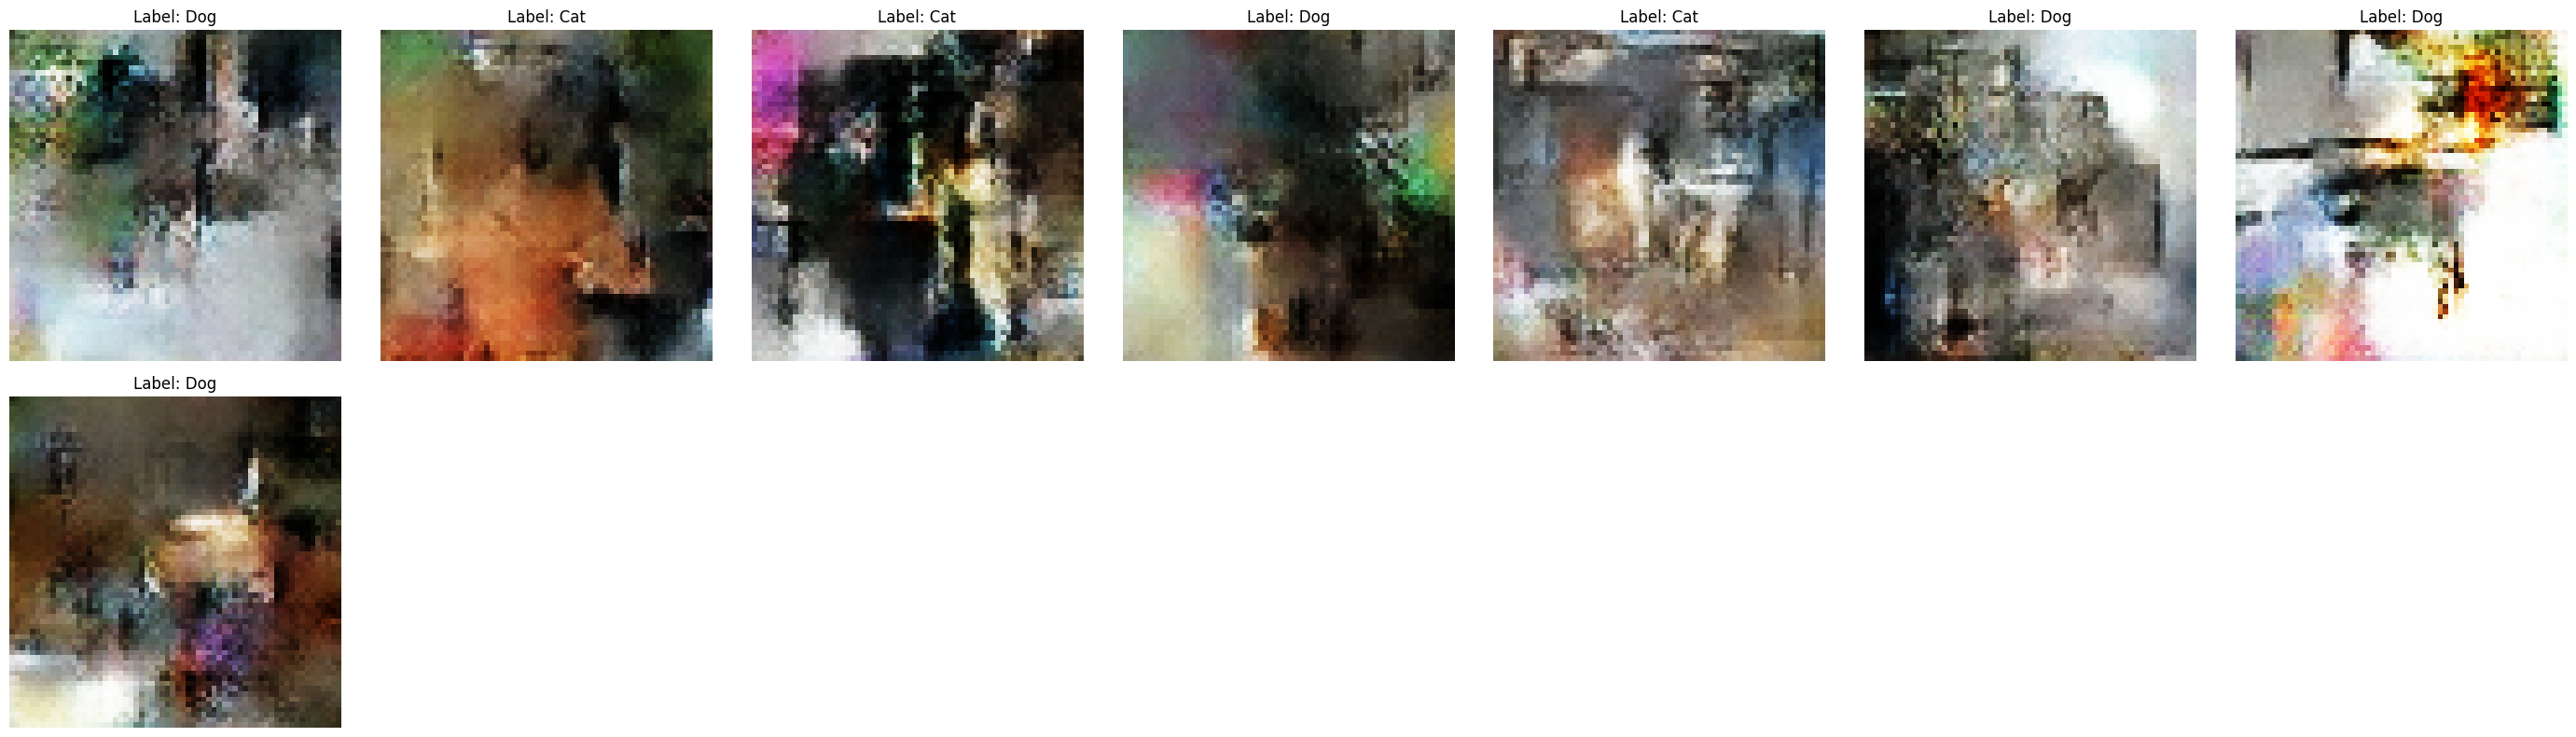

Epoch 141: Gen Loss: 1.0816, Disc Loss: 1.2053
Epoch 142: Gen Loss: 1.0620, Disc Loss: 1.2173
Epoch 142: Gen Loss: 1.0620, Disc Loss: 1.2173
Epoch 143: Gen Loss: 1.0625, Disc Loss: 1.2219
Epoch 143: Gen Loss: 1.0625, Disc Loss: 1.2219
Epoch 144: Gen Loss: 1.0604, Disc Loss: 1.2284
Epoch 144: Gen Loss: 1.0604, Disc Loss: 1.2284
Epoch 145: Gen Loss: 1.0548, Disc Loss: 1.2257
Epoch 145: Gen Loss: 1.0548, Disc Loss: 1.2257
Epoch 146: Gen Loss: 1.0562, Disc Loss: 1.2319
Epoch 146: Gen Loss: 1.0562, Disc Loss: 1.2319
Epoch 147: Gen Loss: 1.0416, Disc Loss: 1.2532
Epoch 147: Gen Loss: 1.0416, Disc Loss: 1.2532
Epoch 148: Gen Loss: 1.0378, Disc Loss: 1.2356
Epoch 148: Gen Loss: 1.0378, Disc Loss: 1.2356
Epoch 149: Gen Loss: 1.0346, Disc Loss: 1.2336
Epoch 149: Gen Loss: 1.0346, Disc Loss: 1.2336
Epoch 150: Gen Loss: 1.0297, Disc Loss: 1.2420
Epoch 150: Gen Loss: 1.0297, Disc Loss: 1.2420


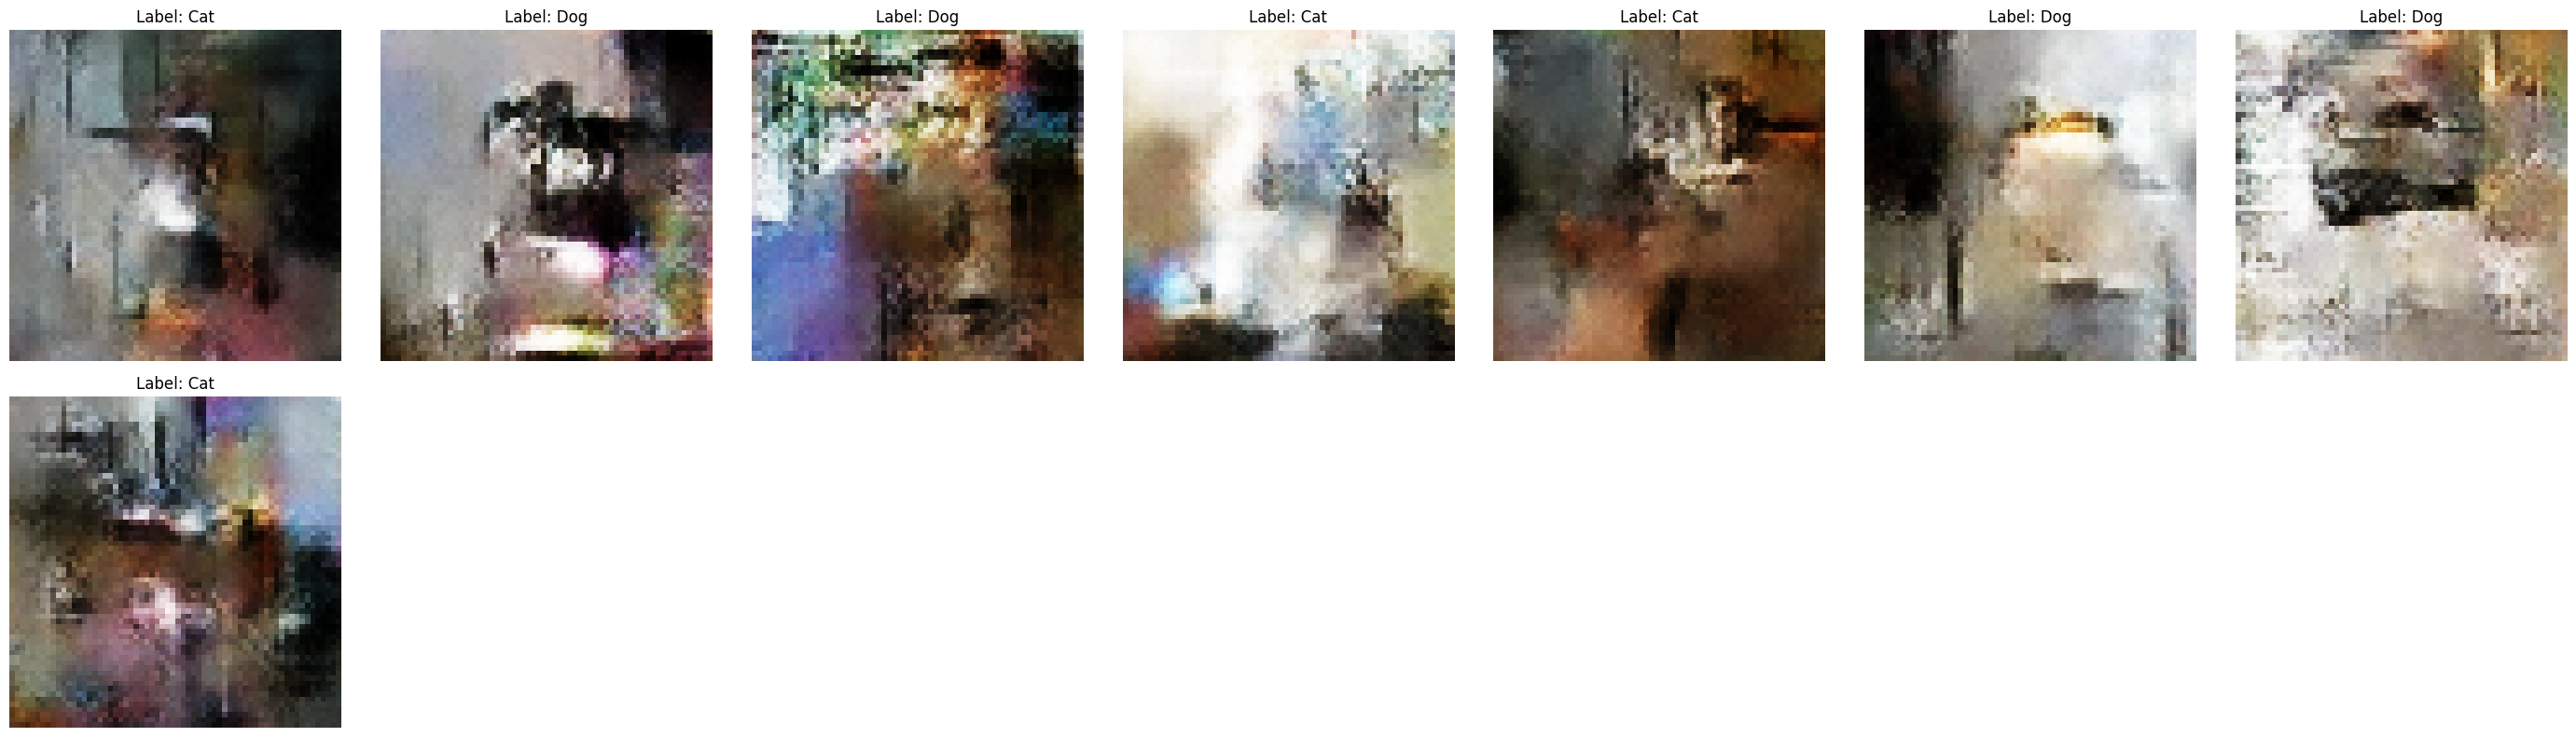

Epoch 151: Gen Loss: 1.0322, Disc Loss: 1.2330
Epoch 152: Gen Loss: 1.0298, Disc Loss: 1.2466
Epoch 152: Gen Loss: 1.0298, Disc Loss: 1.2466
Epoch 153: Gen Loss: 1.0370, Disc Loss: 1.2559
Epoch 153: Gen Loss: 1.0370, Disc Loss: 1.2559
Epoch 154: Gen Loss: 1.0180, Disc Loss: 1.2364
Epoch 154: Gen Loss: 1.0180, Disc Loss: 1.2364
Epoch 155: Gen Loss: 1.0195, Disc Loss: 1.2512
Epoch 155: Gen Loss: 1.0195, Disc Loss: 1.2512
Epoch 156: Gen Loss: 1.0149, Disc Loss: 1.2456
Epoch 156: Gen Loss: 1.0149, Disc Loss: 1.2456
Epoch 157: Gen Loss: 1.0141, Disc Loss: 1.2582
Epoch 157: Gen Loss: 1.0141, Disc Loss: 1.2582
Epoch 158: Gen Loss: 1.0079, Disc Loss: 1.2464
Epoch 158: Gen Loss: 1.0079, Disc Loss: 1.2464
Epoch 159: Gen Loss: 1.0161, Disc Loss: 1.2730
Epoch 159: Gen Loss: 1.0161, Disc Loss: 1.2730
Epoch 160: Gen Loss: 1.0095, Disc Loss: 1.2503
Epoch 160: Gen Loss: 1.0095, Disc Loss: 1.2503


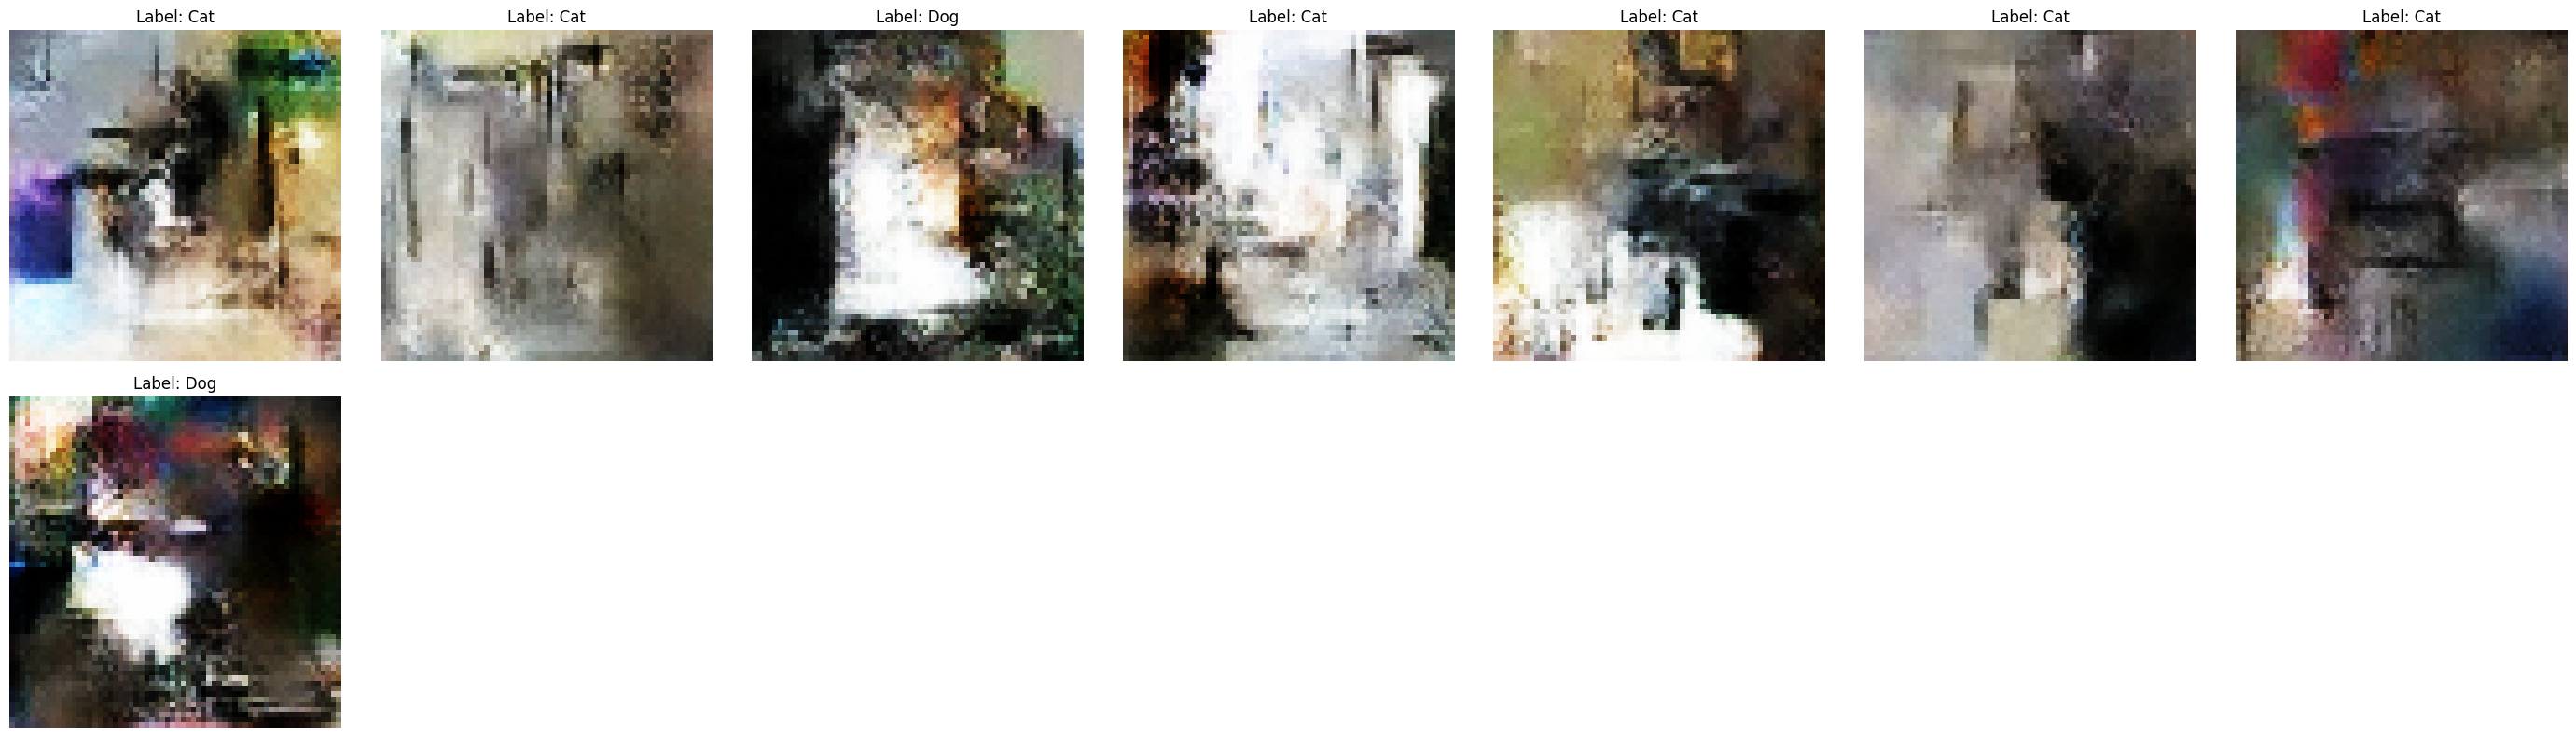

Epoch 161: Gen Loss: 1.0016, Disc Loss: 1.2558
Epoch 162: Gen Loss: 1.0066, Disc Loss: 1.2599
Epoch 162: Gen Loss: 1.0066, Disc Loss: 1.2599
Epoch 163: Gen Loss: 1.0169, Disc Loss: 1.2781
Epoch 163: Gen Loss: 1.0169, Disc Loss: 1.2781
Epoch 164: Gen Loss: 1.4659, Disc Loss: 1.1327
Epoch 164: Gen Loss: 1.4659, Disc Loss: 1.1327
Epoch 165: Gen Loss: 1.6437, Disc Loss: 0.9658
Epoch 165: Gen Loss: 1.6437, Disc Loss: 0.9658
Epoch 166: Gen Loss: 1.6603, Disc Loss: 0.9521
Epoch 166: Gen Loss: 1.6603, Disc Loss: 0.9521
Epoch 167: Gen Loss: 1.6605, Disc Loss: 0.9138
Epoch 167: Gen Loss: 1.6605, Disc Loss: 0.9138
Epoch 168: Gen Loss: 1.5384, Disc Loss: 0.9668
Epoch 168: Gen Loss: 1.5384, Disc Loss: 0.9668
Epoch 169: Gen Loss: 1.3637, Disc Loss: 1.0395
Epoch 169: Gen Loss: 1.3637, Disc Loss: 1.0395
Epoch 170: Gen Loss: 1.1973, Disc Loss: 1.1187
Epoch 170: Gen Loss: 1.1973, Disc Loss: 1.1187


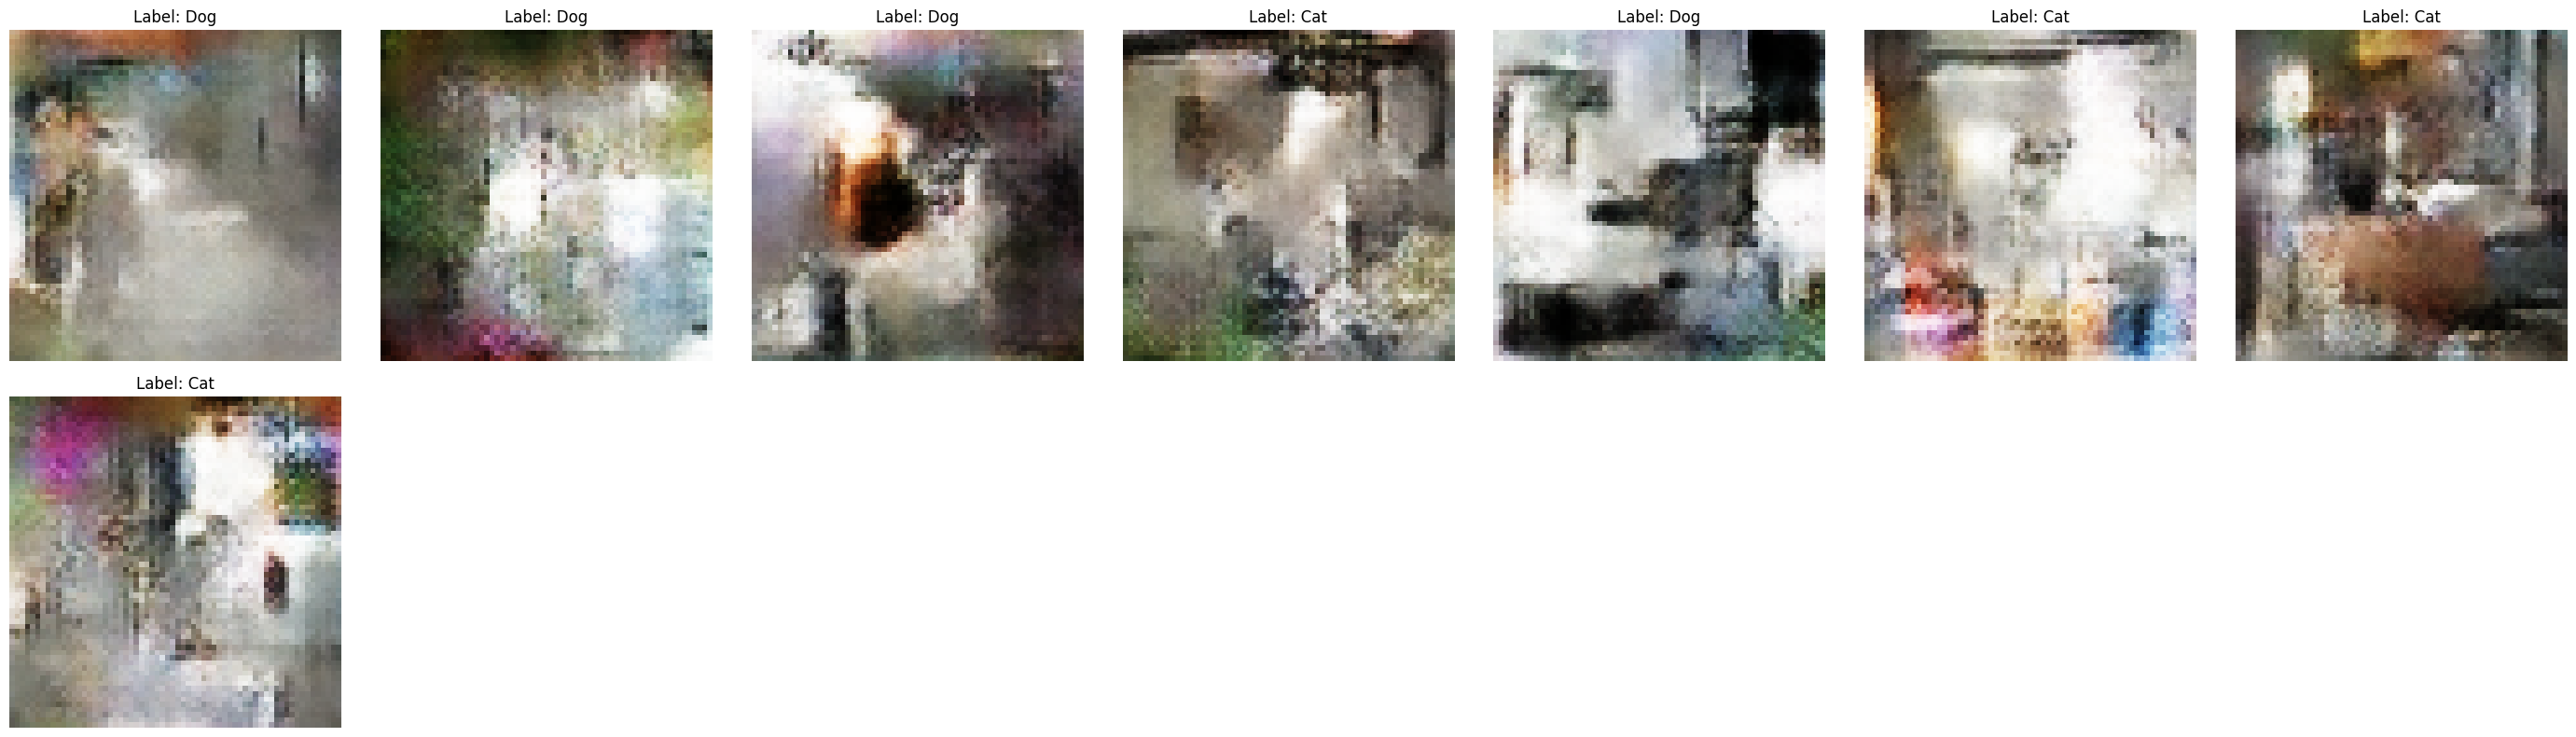

Epoch 171: Gen Loss: 1.1628, Disc Loss: 1.1571
Epoch 172: Gen Loss: 1.1601, Disc Loss: 1.1782
Epoch 172: Gen Loss: 1.1601, Disc Loss: 1.1782
Epoch 173: Gen Loss: 1.1376, Disc Loss: 1.1779
Epoch 173: Gen Loss: 1.1376, Disc Loss: 1.1779
Epoch 174: Gen Loss: 1.1285, Disc Loss: 1.1854
Epoch 174: Gen Loss: 1.1285, Disc Loss: 1.1854
Epoch 175: Gen Loss: 1.1220, Disc Loss: 1.1942
Epoch 175: Gen Loss: 1.1220, Disc Loss: 1.1942
Epoch 176: Gen Loss: 1.1124, Disc Loss: 1.2018
Epoch 176: Gen Loss: 1.1124, Disc Loss: 1.2018
Epoch 177: Gen Loss: 1.0911, Disc Loss: 1.2128
Epoch 177: Gen Loss: 1.0911, Disc Loss: 1.2128
Epoch 178: Gen Loss: 1.0871, Disc Loss: 1.2068
Epoch 178: Gen Loss: 1.0871, Disc Loss: 1.2068
Epoch 179: Gen Loss: 1.0723, Disc Loss: 1.2123
Epoch 179: Gen Loss: 1.0723, Disc Loss: 1.2123
Epoch 180: Gen Loss: 1.0643, Disc Loss: 1.2282
Epoch 180: Gen Loss: 1.0643, Disc Loss: 1.2282


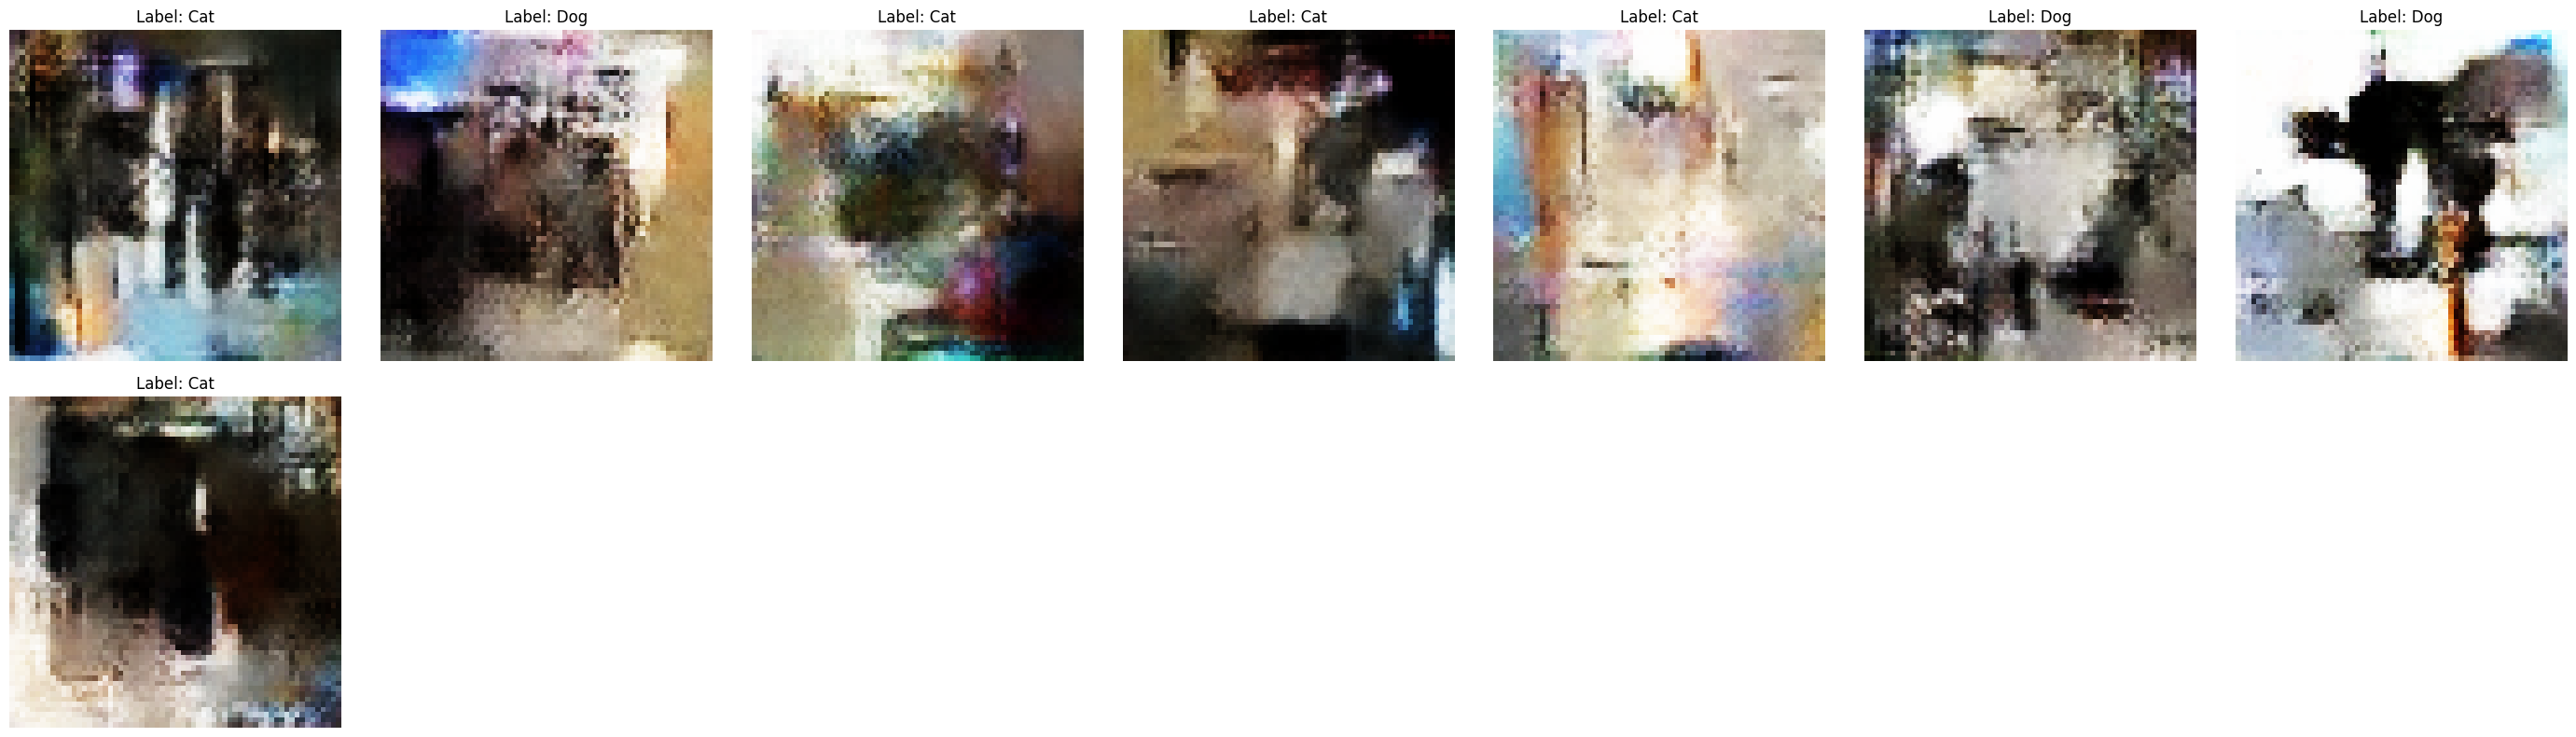

Epoch 181: Gen Loss: 1.0573, Disc Loss: 1.2290
Epoch 182: Gen Loss: 1.0699, Disc Loss: 1.2351
Epoch 182: Gen Loss: 1.0699, Disc Loss: 1.2351
Epoch 183: Gen Loss: 1.0473, Disc Loss: 1.2358
Epoch 183: Gen Loss: 1.0473, Disc Loss: 1.2358
Epoch 184: Gen Loss: 1.0347, Disc Loss: 1.2424
Epoch 184: Gen Loss: 1.0347, Disc Loss: 1.2424
Epoch 185: Gen Loss: 1.0336, Disc Loss: 1.2421
Epoch 185: Gen Loss: 1.0336, Disc Loss: 1.2421
Epoch 186: Gen Loss: 1.0270, Disc Loss: 1.2538
Epoch 186: Gen Loss: 1.0270, Disc Loss: 1.2538
Epoch 187: Gen Loss: 1.0313, Disc Loss: 1.2491
Epoch 187: Gen Loss: 1.0313, Disc Loss: 1.2491
Epoch 188: Gen Loss: 1.0295, Disc Loss: 1.2443
Epoch 188: Gen Loss: 1.0295, Disc Loss: 1.2443
Epoch 189: Gen Loss: 1.0237, Disc Loss: 1.2498
Epoch 189: Gen Loss: 1.0237, Disc Loss: 1.2498
Epoch 190: Gen Loss: 1.0303, Disc Loss: 1.2607
Epoch 190: Gen Loss: 1.0303, Disc Loss: 1.2607


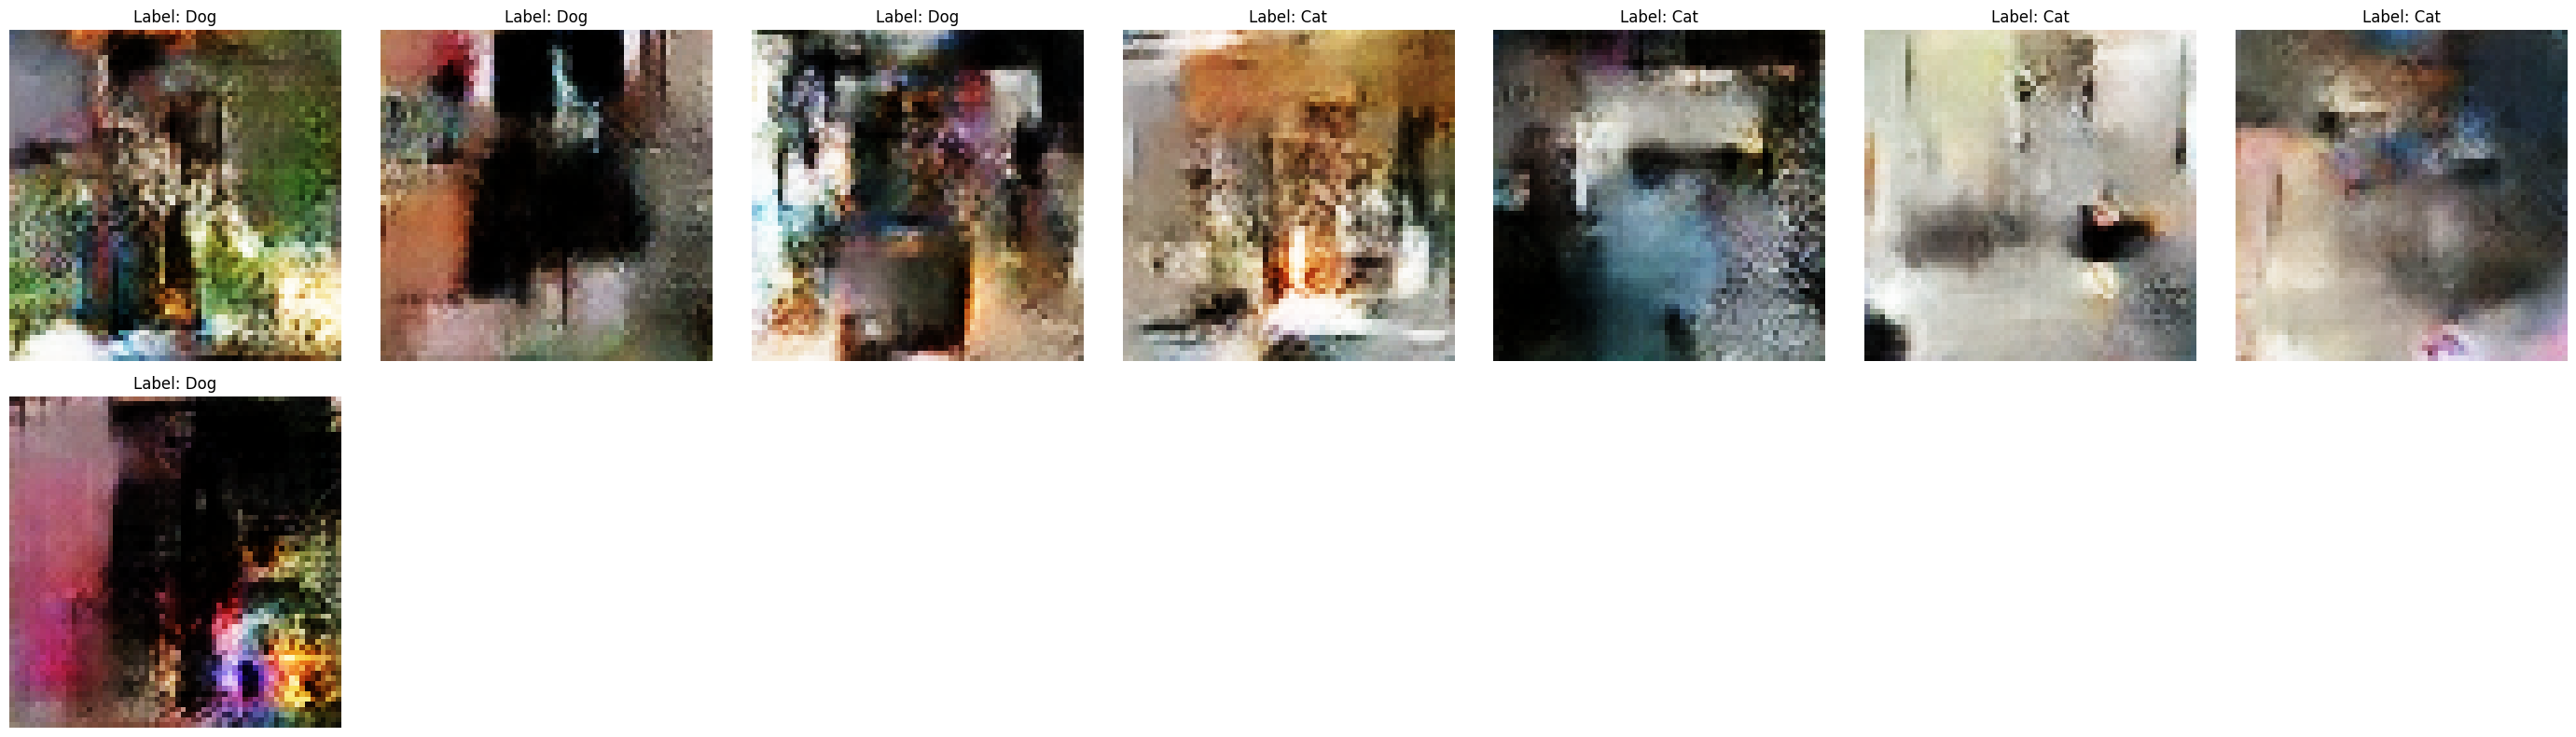

Epoch 191: Gen Loss: 1.0134, Disc Loss: 1.2603
Epoch 192: Gen Loss: 1.0244, Disc Loss: 1.2482
Epoch 192: Gen Loss: 1.0244, Disc Loss: 1.2482
Epoch 193: Gen Loss: 1.0227, Disc Loss: 1.2465
Epoch 193: Gen Loss: 1.0227, Disc Loss: 1.2465
Epoch 194: Gen Loss: 1.0224, Disc Loss: 1.2703
Epoch 194: Gen Loss: 1.0224, Disc Loss: 1.2703
Epoch 195: Gen Loss: 1.0012, Disc Loss: 1.2575
Epoch 195: Gen Loss: 1.0012, Disc Loss: 1.2575
Epoch 196: Gen Loss: 1.0119, Disc Loss: 1.2596
Epoch 196: Gen Loss: 1.0119, Disc Loss: 1.2596
Epoch 197: Gen Loss: 1.0103, Disc Loss: 1.2607
Epoch 197: Gen Loss: 1.0103, Disc Loss: 1.2607
Epoch 198: Gen Loss: 0.9979, Disc Loss: 1.2664
Epoch 198: Gen Loss: 0.9979, Disc Loss: 1.2664
Epoch 199: Gen Loss: 0.9992, Disc Loss: 1.2485
Epoch 199: Gen Loss: 0.9992, Disc Loss: 1.2485
Epoch 200: Gen Loss: 1.0200, Disc Loss: 1.2763
Epoch 200: Gen Loss: 1.0200, Disc Loss: 1.2763


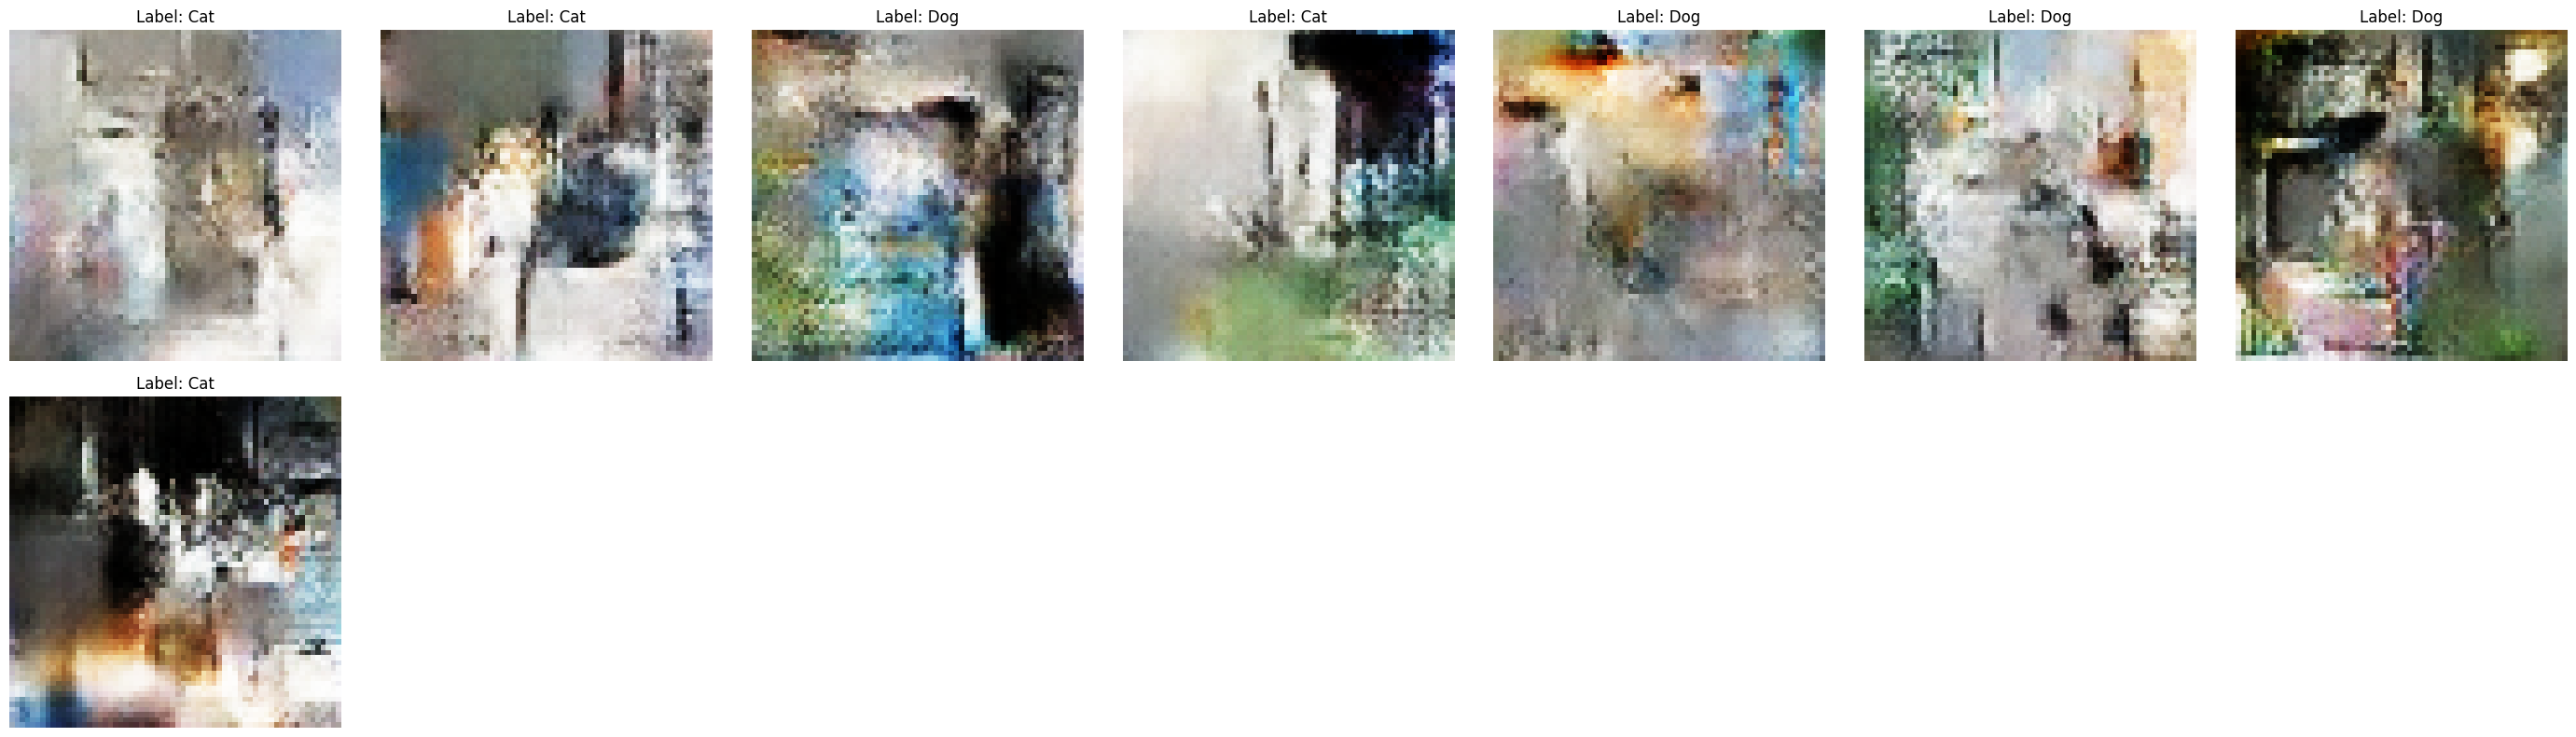

In [25]:

@tf.function
def train_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate fake images conditioned on labels
        generated_images = generator([noise, labels], training=True)

        # 2. Get discriminator outputs for real and fake images
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        # 3. Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 4. Apply gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # 5. Update weights
    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

# Metrics for tracking average epoch losses
gen_loss_tracker = keras.metrics.Mean(name="gen_loss")
disc_loss_tracker = keras.metrics.Mean(name="disc_loss")

# Training Loop
for epoch in range(EPOCHS):
    gen_loss_tracker.reset_state()
    disc_loss_tracker.reset_state()
    for image_batch, label_batch in train_dataset:        
        if image_batch.shape[0] == BATCH_SIZE:
            g_loss, d_loss = train_step(image_batch, label_batch)
            gen_loss_tracker.update_state(g_loss)
            disc_loss_tracker.update_state(d_loss)
            
    print(f"Epoch {epoch+1}: Gen Loss: {gen_loss_tracker.result():.4f}, Disc Loss: {disc_loss_tracker.result():.4f}")
    if (epoch + 1) % 10 == 0:
        generate_and_plot(num_examples=8) 

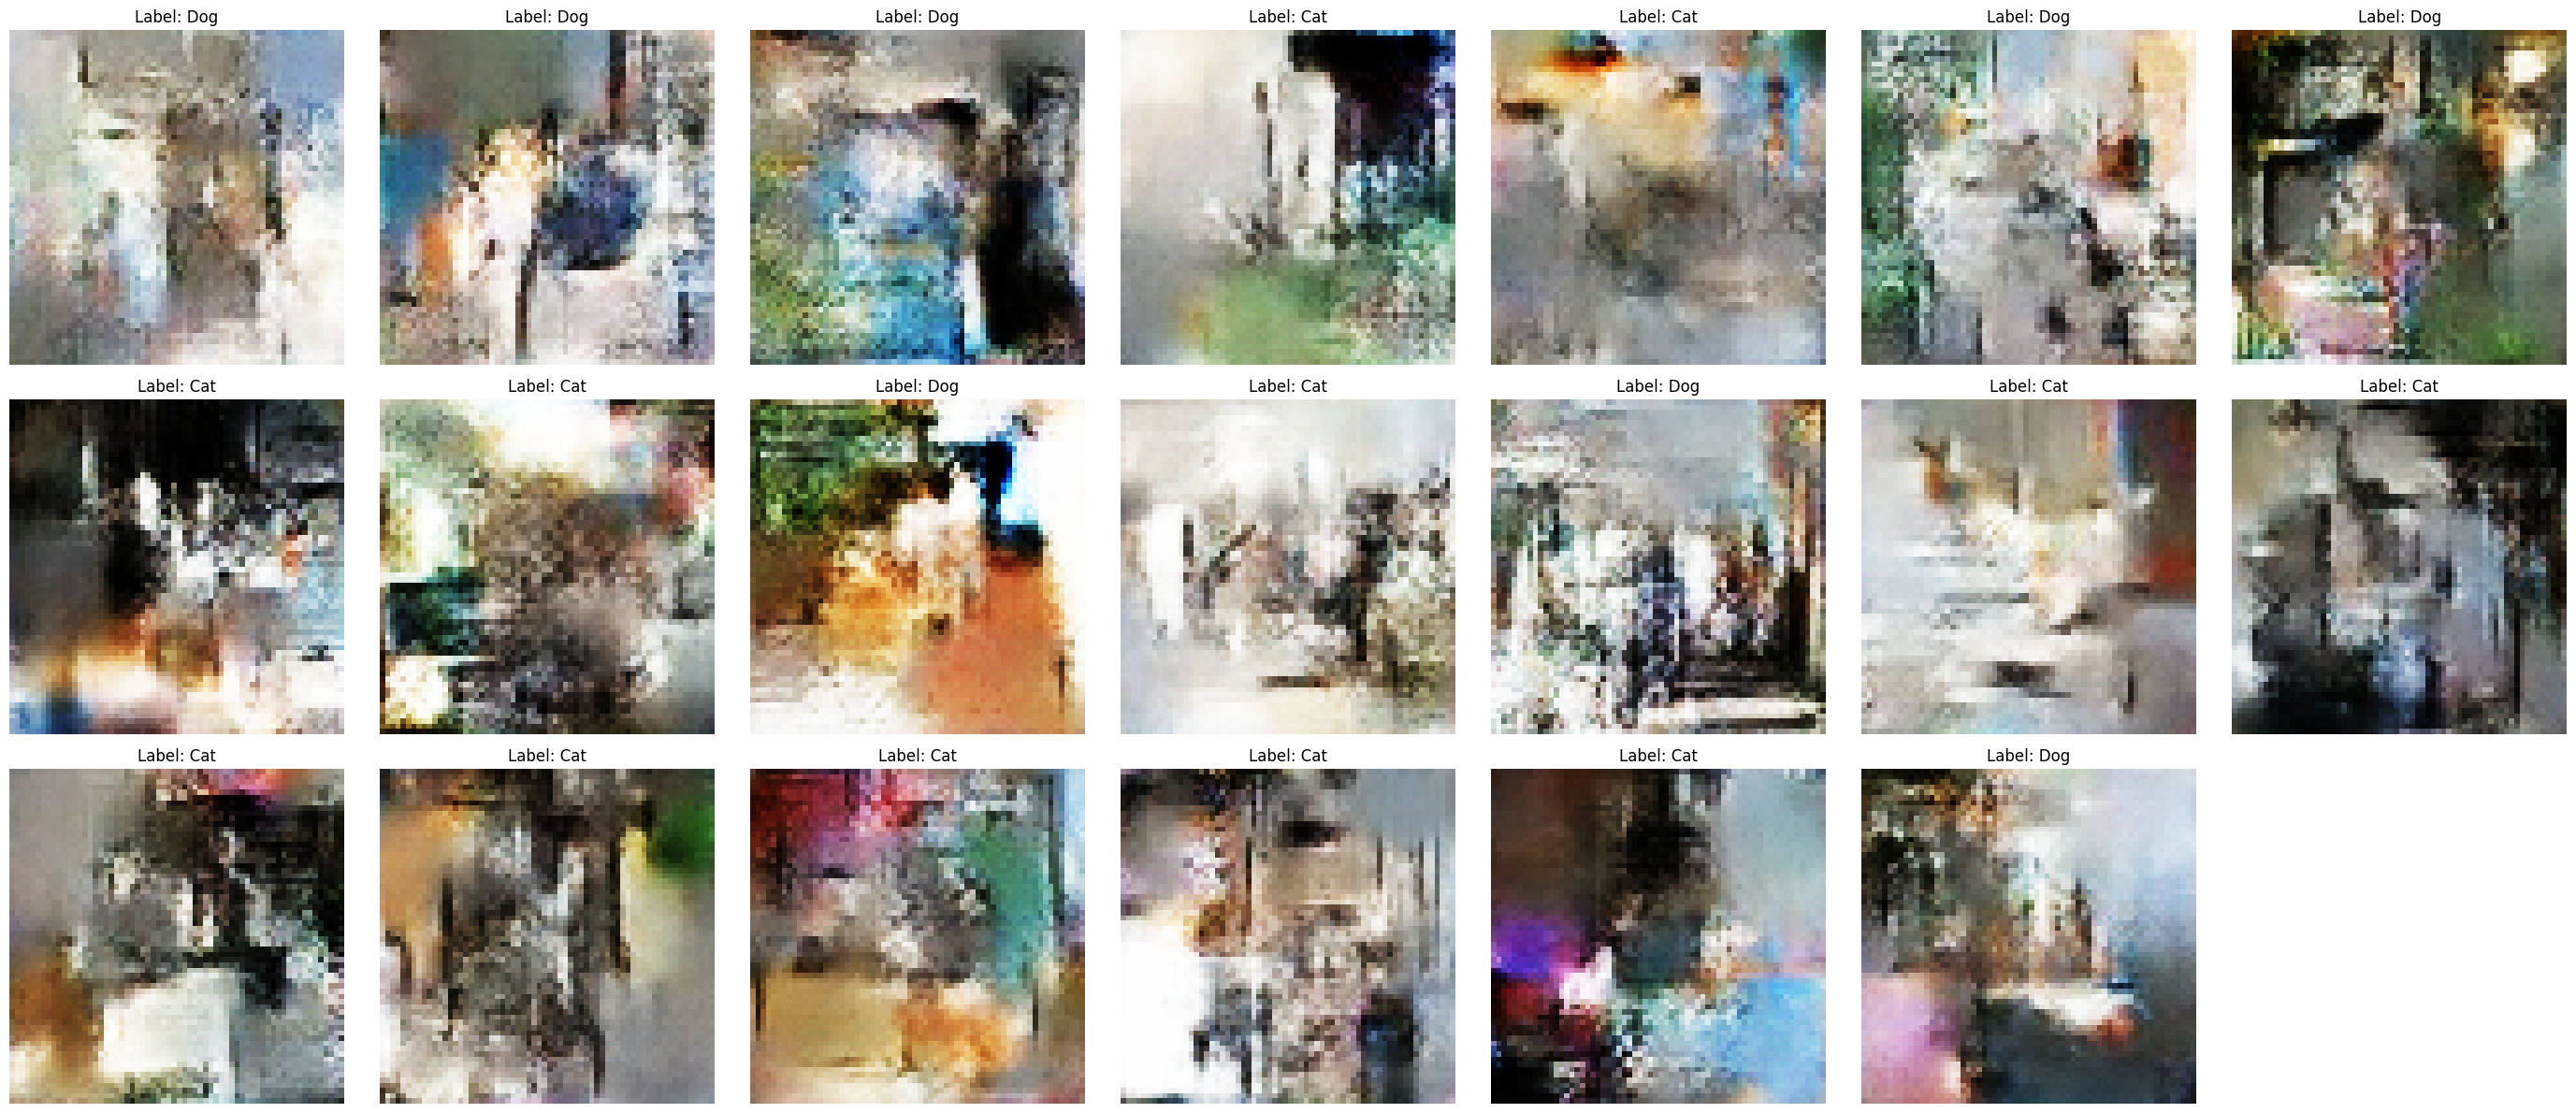

In [26]:
# Visualize results
generate_and_plot(20)